In [1]:
# 网络结构和激活函数
# 网络结构：神经元个数、网络层数（网络深度）、每层神经元的个数又称为网络宽度；
# 不同宽度、深度的网络模型有不同的拟合能力
# 问题：运算量暴增、梯度消失、梯度爆炸

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator
from math import sqrt
from numpy import concatenate
from pandas import read_csv, DataFrame, concat
from datetime import datetime
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import MinMaxScaler, StandardScaler

import keras.backend as K
from keras.layers import Multiply
from keras.models import Sequential ,Model
from keras.layers import Dense , Input , Reshape , Flatten ,Permute , Lambda , RepeatVector ,Conv1D , MaxPooling1D , Dropout, Bidirectional, Activation
from keras.layers import GRU, LSTM
from keras.utils.vis_utils import plot_model
from keras.optimizers import SGD,Adam
from keras.utils import np_utils   #np_utils
from keras.callbacks import TensorBoard  #TensorBoard可视化


Using TensorFlow backend.


In [3]:
# T:0
# H:1
# Surge:2
# Heave:4
# Force1:8
data_1 = pd.read_csv('t_1.csv')
data_1.head()

,T,H,Surge,Sway,Heave,Roll,Pitch,Yaw,Force1,Force2
0,0.1,-277.0,-2.36,0.000849,-15.1,3.230000e-09,-0.0121,-1.980000e-09,4890.0,5070.0
1,1.1,-591.0,-30.10,-0.185000,-448.0,3.090000e-05,-0.0156,-1.650000e-05,4260.0,4680.0
2,2.1,-457.0,-112.00,1.570000,-422.0,5.970000e-04,0.0303,1.440000e-04,4320.0,4680.0
3,3.1,85.5,28.00,-0.265000,51.0,-3.080000e-04,0.0570,1.300000e-04,5580.0,4610.0
4,4.1,618.0,95.70,-2.900000,488.0,3.310000e-05,0.0352,2.270000e-04,6180.0,5040.0


In [4]:
data_distance = np.hstack((np.array(data_1)[:, 1:8], np.array(data_1)[:, 8:10]))
print(data_distance)
print(data_distance.shape)

H_scaler = MinMaxScaler(feature_range=(-1, 1))
H = H_scaler.fit_transform(data_distance[:,0:1])
Surge_scaler = MinMaxScaler(feature_range=(-1, 1))
Surge = Surge_scaler.fit_transform(data_distance[:,1:2])
Sway_scaler = MinMaxScaler(feature_range=(-1, 1))
Sway = Sway_scaler.fit_transform(data_distance[:,2:3])
Heave_scaler = MinMaxScaler(feature_range=(-1, 1))
Heave = Heave_scaler.fit_transform(data_distance[:,3:4])
Roll_scaler = MinMaxScaler(feature_range=(-1, 1))
Roll = Roll_scaler.fit_transform(data_distance[:,4:5])
Pitch_scaler = MinMaxScaler(feature_range=(-1, 1))
Pitch = Pitch_scaler.fit_transform(data_distance[:,5:6])
Yaw_scaler = MinMaxScaler(feature_range=(-1, 1))
Yaw = Yaw_scaler.fit_transform(data_distance[:,6:7])
Force1_scaler = MinMaxScaler(feature_range=(-1, 1))
Force1 = Force1_scaler.fit_transform(data_distance[:,7:8])
Force2_scaler = MinMaxScaler(feature_range=(-1, 1))
Force2 = Force1_scaler.fit_transform(data_distance[:,8:9])
# zong_data = np.hstack(())

[[-2.77e+02 -2.36e+00  8.49e-04 ... -1.98e-09  4.89e+03  5.07e+03]
 [-5.91e+02 -3.01e+01 -1.85e-01 ... -1.65e-05  4.26e+03  4.68e+03]
 [-4.57e+02 -1.12e+02  1.57e+00 ...  1.44e-04  4.32e+03  4.68e+03]
 ...
 [ 3.29e+02  1.75e+02 -6.20e+00 ... -6.95e-05  6.32e+03  4.61e+03]
 [ 8.32e+02  1.92e+02 -3.20e+00 ...  4.27e-04  6.59e+03  4.96e+03]
 [ 7.99e+02  1.13e+02  1.83e+00 ...  8.30e-05  6.02e+03  5.51e+03]]
(11000, 9)


In [5]:
np.savetxt('MinMaxScaler_data.csv',np.hstack((Heave,Surge,Pitch)),delimiter=',')

#### 预处理 散点图

In [88]:
def DataScatter_Plot(data_x, data_y, y_arange, scatter_size, color, Inter_xaxis, Inter_yaxis):
    fig = plt.figure(figsize=(5.2,3.8))
    # 将x周的刻度线方向设置向内
    plt.rcParams['xtick.direction'] = 'in'  
    # 将y轴的刻度方向设置向内
    plt.rcParams['ytick.direction'] = 'in'  
    #设置字体以便支持中文
    plt.rcParams['font.sans-serif']=['SongNTR']
    #为正常显示负号
    plt.rcParams['axes.unicode_minus'] = False 
    fig.subplots_adjust(hspace=0.1, wspace=0.1)
    axes = plt.subplot()
    axes.minorticks_on()
    axes.tick_params(axis="both", which="major", direction="in", width=1, length=5)
    axes.tick_params(axis="both", which="minor", direction="in", width=1, length=3)
    axes.xaxis.set_minor_locator(MultipleLocator(Inter_xaxis))
    axes.yaxis.set_minor_locator(MultipleLocator(Inter_yaxis))
    plt.scatter(data_x, data_y, scatter_size, c=color)
    plt.xlabel("x", font='Times New Roman', fontsize=24)
    plt.ylabel("y", font='Times New Roman', fontsize=24)
    plt.xticks([0,2500,5000,7500,10000], fontsize=24)
    plt.yticks(y_arange, fontsize=24)
    plt.xlim(0, 11000)
    #plt.ylim(-2, 16)
    #plt.legend(loc='lower right', prop={'family':'Times New Roman', 'size':10})
    #plt.xlabel('Time(s)', fontdict={'family' : 'Times New Roman', 'size':10})
    #plt.grid(True, which="major", linestyle="--", color="gray", linewidth=0.75)
    #plt.grid(True, which="minor", linestyle=":", color="lightgray", linewidth=0.75)
    plt.show()

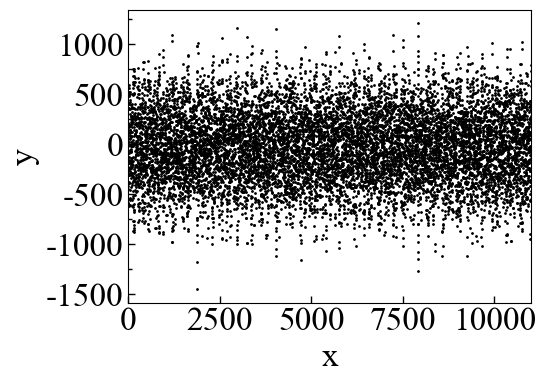

In [91]:
DataScatter_Plot(np.arange(1,11001,1), data_distance[:,3:4], y_arange=[-1500,-1000,-500,0,500,1000], scatter_size=1, color="k", Inter_xaxis=2500, Inter_yaxis=250)

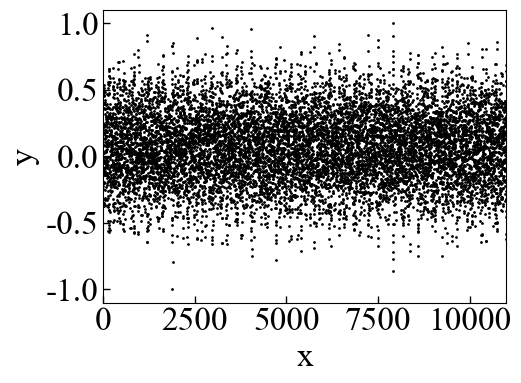

In [92]:
DataScatter_Plot(np.arange(1,11001,1), Heave, y_arange=[-1,-0.5,0,0.5,1], scatter_size=1, color="k", Inter_xaxis=2500, Inter_yaxis=250)

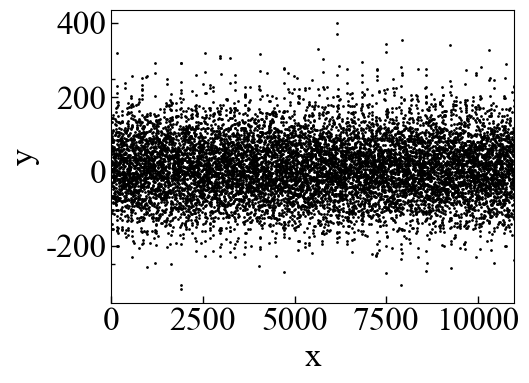

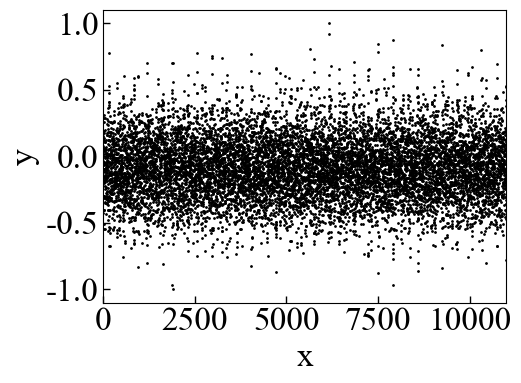

In [89]:
DataScatter_Plot(np.arange(1,11001,1), data_distance[:,1:2], y_arange=[-200,0,200,400], scatter_size=1, color="k", Inter_xaxis=2500, Inter_yaxis=250)
DataScatter_Plot(np.arange(1,11001,1), Surge, y_arange=[-1,-0.5,0,0.5,1], scatter_size=1, color="k", Inter_xaxis=2500, Inter_yaxis=250)

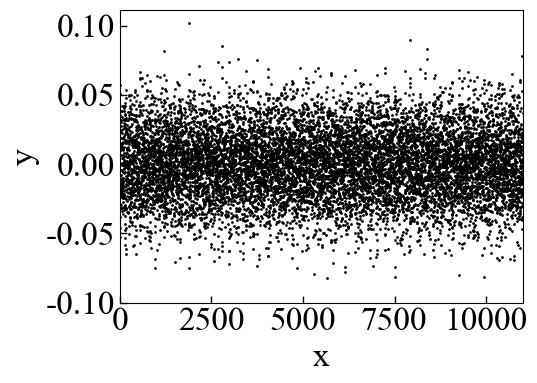

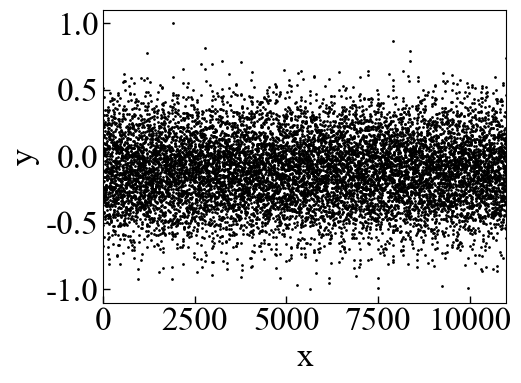

In [90]:
DataScatter_Plot(np.arange(1,11001,1), data_distance[:,5:6],  y_arange=[-0.1,-0.05,0,0.05,0.1], scatter_size=1, color="k", Inter_xaxis=2500, Inter_yaxis=250)
DataScatter_Plot(np.arange(1,11001,1), Pitch, y_arange=[-1,-0.5,0,0.5,1], scatter_size=1, color="k", Inter_xaxis=2500, Inter_yaxis=250)

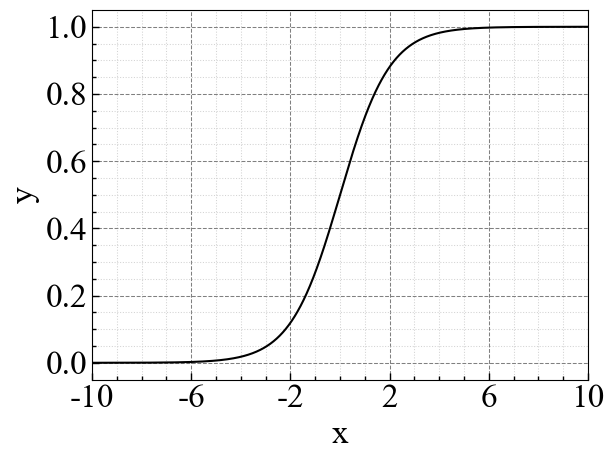

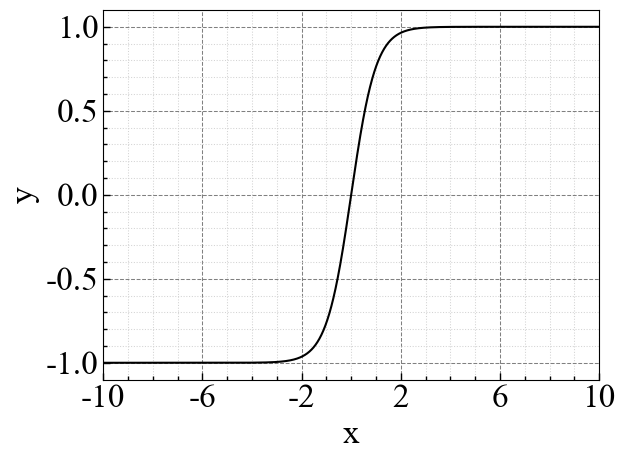

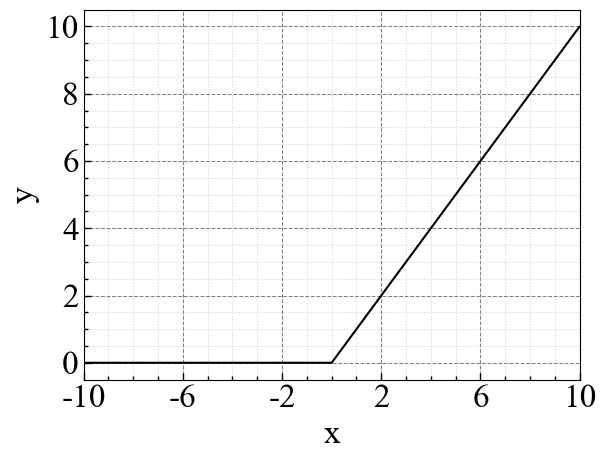

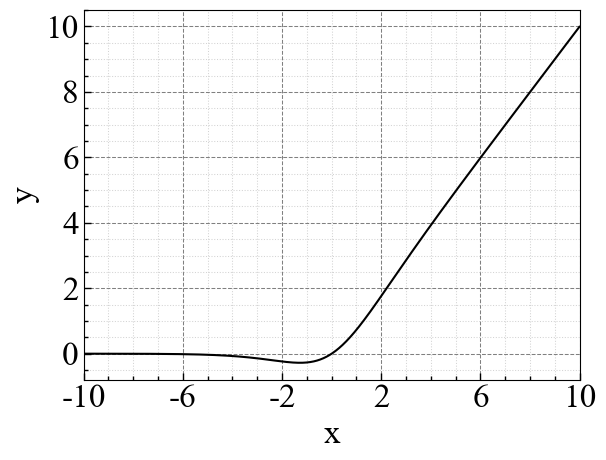

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

def sigmoid(x):
    return 1 / (1 + np.exp(-x))    

def tanh(x):
    return (np.exp(x)-np.exp(-x)) /(np.exp(x)+np.exp(-x)) 

def relu(x):
    return np.maximum(0, x)

def swish(x,beta=1.0):
    return x*sigmoid(beta*x)
def Function_Plot(function, a):
    x = np.arange(-10, 10, 0.01)
    #y = np.arange(-2, 10, 0.01)
    fig = plt.figure()
    # 将x周的刻度线方向设置向内
    plt.rcParams['xtick.direction'] = 'in'  
    # 将y轴的刻度方向设置向内
    plt.rcParams['ytick.direction'] = 'in'  
    #设置字体以便支持中文
    plt.rcParams['font.sans-serif']=['SongNTR']
    #为正常显示负号
    plt.rcParams['axes.unicode_minus'] = False 
    fig.subplots_adjust(hspace=0.1, wspace=0.1)
    axes = plt.subplot()
    axes.minorticks_on()
    axes.tick_params(axis="both", which="major", direction="in", width=1, length=5)
    axes.tick_params(axis="both", which="minor", direction="in", width=1, length=3)
    axes.xaxis.set_minor_locator(MultipleLocator(1))
    plt.plot(x, function(x),'black')
    plt.xlabel("x", font='Times New Roman', fontsize=24)
    plt.ylabel("y", font='Times New Roman', fontsize=24)
    plt.xticks([-10,-6,-2,2,6,10], fontsize=24)
    plt.yticks(a, fontsize=24)
    plt.xlim(-10, 10)
    #plt.ylim(-2, 16)
    #plt.legend(loc='lower right', prop={'family':'Times New Roman', 'size':10})
    #plt.xlabel('Time(s)', fontdict={'family' : 'Times New Roman', 'size':10})
    plt.grid(True, which="major", linestyle="--", color="gray", linewidth=0.75)
    plt.grid(True, which="minor", linestyle=":", color="lightgray", linewidth=0.75)
    plt.show()
    

Function_Plot(sigmoid, [0,0.2,0.4,0.6,0.8,1])
Function_Plot(tanh, [-1,-0.5,0,0.5,1])
Function_Plot(relu, [0,2,4,6,8,10])
Function_Plot(swish, [0,2,4,6,8,10])

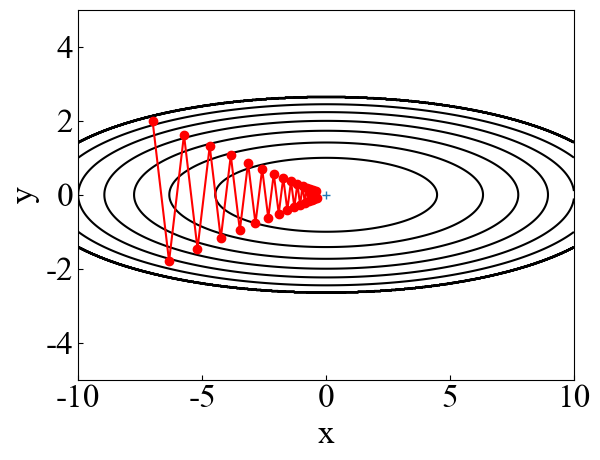

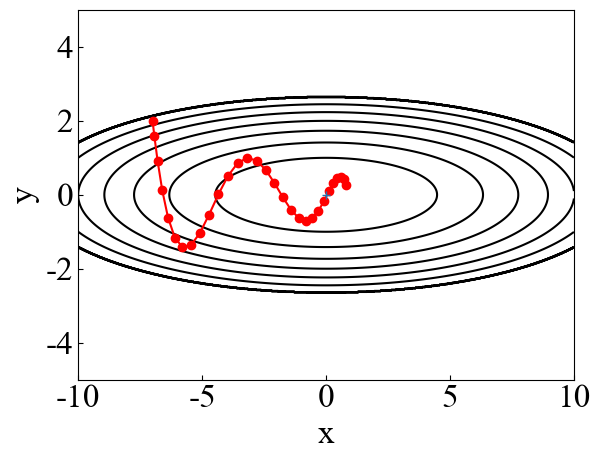

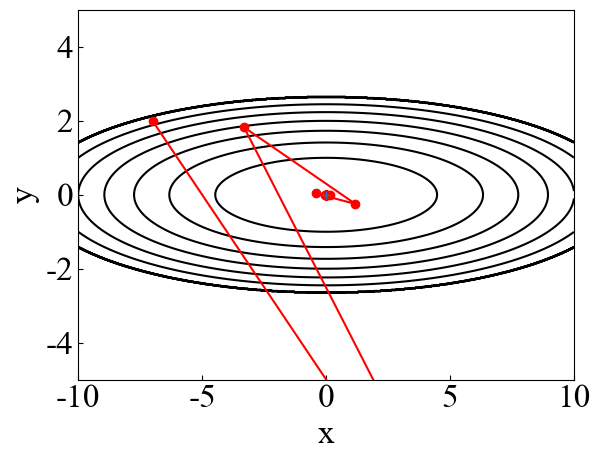

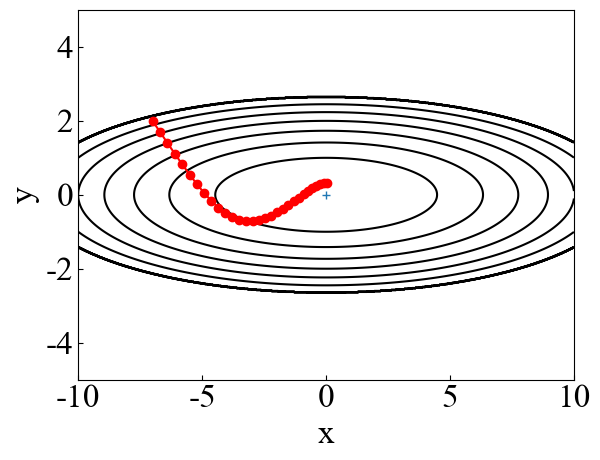

In [2]:
#比较优化器：SGD, Momentum, AdaGrad, Adam(静态图)
import sys, os
sys.path.append(os.pardir)  # 为了导入父目录的文件而进行的设定
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from common.optimizer import *


def f(x, y):
    return x**2 / 20.0 + y**2


def df(x, y):
    return x / 10.0, 2.0*y

init_pos = (-7.0, 2.0)
params = {}
params['x'], params['y'] = init_pos[0], init_pos[1]
grads = {}
grads['x'], grads['y'] = 0, 0


optimizers = OrderedDict()
optimizers["SGD"] = SGD(lr=0.95)
optimizers["Momentum"] = Momentum(lr=0.1)
optimizers["RMSprop"] = RMSprop(lr=1.5)  #AdaGrad
optimizers["Adam"] = Adam(lr=0.3)

idx = 1

for key in optimizers:
    optimizer = optimizers[key]
    x_history = []
    y_history = []
    params['x'], params['y'] = init_pos[0], init_pos[1]
    
    for i in range(30):
        x_history.append(params['x'])
        y_history.append(params['y'])
        
        grads['x'], grads['y'] = df(params['x'], params['y'])
        optimizer.update(params, grads)
    

    x = np.arange(-10, 10, 0.01)
    y = np.arange(-5, 5, 0.01)
    
    X, Y = np.meshgrid(x, y) 
    Z = f(X, Y)
    
    # for simple contour line  
    mask = Z > 7
    Z[mask] = 0
    
    # plot 
    #with plt.style.context(['science','no-latex']):
    fig = plt.figure()
    # 将x周的刻度线方向设置向内
    plt.rcParams['xtick.direction'] = 'in'  
    # 将y轴的刻度方向设置向内
    plt.rcParams['ytick.direction'] = 'in'  
    #设置字体以便支持中文
    plt.rcParams['font.sans-serif']=['SimHei']
    #为正常显示负号
    plt.rcParams['axes.unicode_minus'] = False 
    #plt.subplot(2, 2, idx)
    idx += 1
    fig.subplots_adjust(hspace=0.1, wspace=0.1)
    plt.contour(X, Y, Z, colors="black")
    plt.plot(x_history, y_history, 'o-', color="red")
    plt.ylim(-5, 5)
    plt.xlim(-10, 10)
    plt.plot(0, 0, '+')
    #colorbar()
    #spring()
    #plt.title(key) 
    plt.xlabel("x", font='Times New Roman', fontsize=24)
    plt.ylabel("y", font='Times New Roman', fontsize=24)
    plt.xticks(np.arange(-10, 11, 5), fontproperties = 'Times New Roman', fontsize=24)
    plt.yticks(fontproperties = 'Times New Roman', fontsize=24)
    #plt.legend(loc='lower right', prop={'family':'Times New Roman', 'size':10})
    #plt.xlabel('Time(s)', fontdict={'family' : 'Times New Roman', 'size':10})
plt.show()

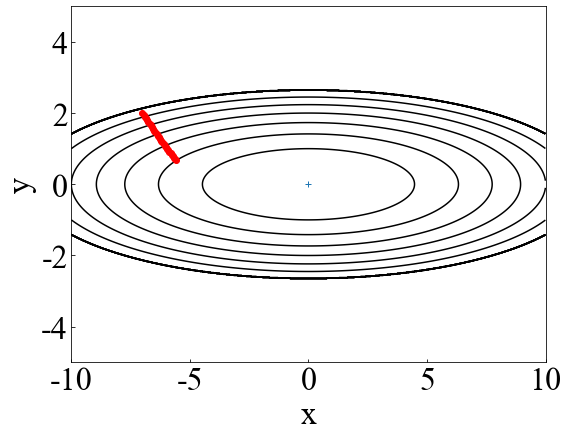

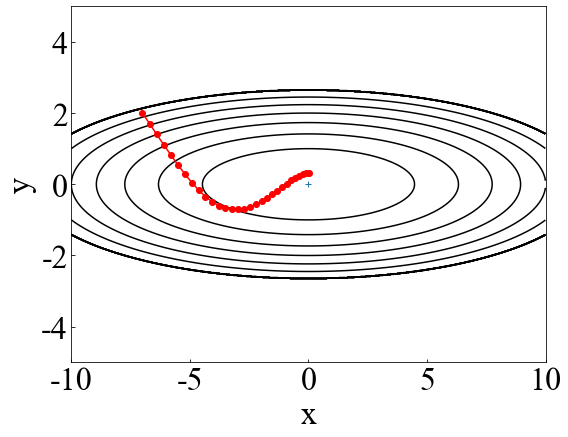

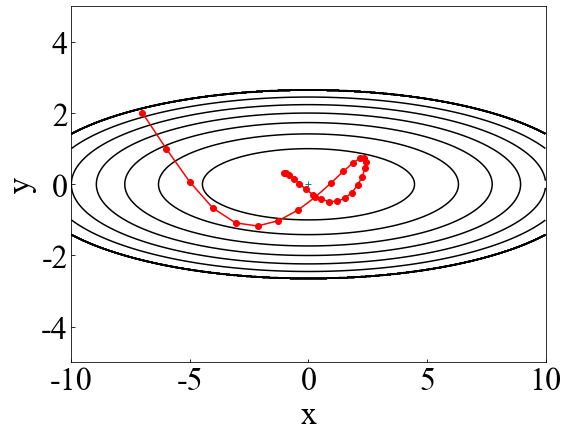

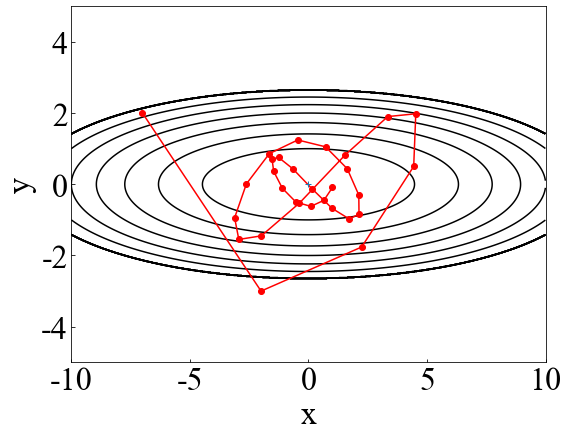

In [26]:
#比较学习率：0.08, 0.3, 1, 5(静态图)
import sys, os
sys.path.append(os.pardir)  # 为了导入父目录的文件而进行的设定
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from common.optimizer import *


def f(x, y):
    return x**2 / 20.0 + y**2


def df(x, y):
    return x / 10.0, 2.0*y

init_pos = (-7.0, 2.0)
params = {}
params['x'], params['y'] = init_pos[0], init_pos[1]
grads = {}
grads['x'], grads['y'] = 0, 0


optimizers = OrderedDict()
optimizers["Adam1"] = Adam(lr=0.05)
optimizers["Adam2"] = Adam(lr=0.3)
optimizers["Adam3"] = Adam(lr=1)  #AdaGrad
optimizers["Adam4"] = Adam(lr=5)

idx = 1

for key in optimizers:
    optimizer = optimizers[key]
    x_history = []
    y_history = []
    params['x'], params['y'] = init_pos[0], init_pos[1]
    
    for i in range(30):
        x_history.append(params['x'])
        y_history.append(params['y'])
        
        grads['x'], grads['y'] = df(params['x'], params['y'])
        optimizer.update(params, grads)
    

    x = np.arange(-10, 10, 0.01)
    y = np.arange(-5, 5, 0.01)
    
    X, Y = np.meshgrid(x, y) 
    Z = f(X, Y)
    
    # for simple contour line  
    mask = Z > 7
    Z[mask] = 0
    
    # plot 
    #with plt.style.context(['science','no-latex']):
    fig = plt.figure(figsize=(8.5,6.55))
    # 将x周的刻度线方向设置向内
    plt.rcParams['xtick.direction'] = 'in'  
    # 将y轴的刻度方向设置向内
    plt.rcParams['ytick.direction'] = 'in'  
    #设置字体以便支持中文
    plt.rcParams['font.sans-serif']=['SimHei']
    #为正常显示负号
    plt.rcParams['axes.unicode_minus'] = False 
    #plt.subplot(2, 2, idx)
    idx += 1
    fig.subplots_adjust(hspace=0.1, wspace=0.1)
    plt.contour(X, Y, Z, colors="black")
    plt.plot(x_history, y_history, 'o-', color="red")
    plt.ylim(-5, 5)
    plt.xlim(-10, 10)
    plt.plot(0, 0, '+')
    #colorbar()
    #spring()
    #plt.title(key) 
    plt.xlabel("x", font='Times New Roman', fontsize=32)
    plt.ylabel("y", font='Times New Roman', fontsize=32)
    plt.xticks(np.arange(-10, 11, 5), fontproperties = 'Times New Roman', fontsize=32)
    plt.yticks(fontproperties = 'Times New Roman', fontsize=32)
    #plt.legend(loc='lower right', prop={'family':'Times New Roman', 'size':10})
    #plt.xlabel('Time(s)', fontdict={'family' : 'Times New Roman', 'size':10})
plt.show()

#### 时序模型A

In [128]:
# GRU
def Model_GRU(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(GRU(25, activation='tanh', return_sequences=True, input_shape=(train_X.shape[1], train_X.shape[2])))  #25×5的数据输入
    model.add(Dropout(0.3))
    model.add(GRU(100, activation='tanh', return_sequences=True))
    model.add(Dropout(0.3))
    model.add(GRU(100, activation='tanh'))
    model.add(Dropout(0.3))
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

# LSTM
def Model_LSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(LSTM(25, activation='tanh', return_sequences=True, input_shape=(train_X.shape[1], train_X.shape[2])))  #25×5的数据输入
    model.add(Dropout(0.3))
    model.add(LSTM(100, activation='tanh', return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(100, activation='tanh'))
    model.add(Dropout(0.3))
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

# BiLSTM
from keras.layers import LeakyReLU
def Model_BiLSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(Bidirectional(LSTM(25, batch_input_shape=(24, train_X.shape[1], train_X.shape[2]),stateful=False), merge_mode='concat'))  #25×5的数据输入
    model.add(LeakyReLU(alpha=0.3))
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

def series_to_supervised(data, n_in, n_out, dropnan=True):
#      '''
#      说明：将每一个特征（输入+输出）的单步-目标步长数全数列举出来
#      '''
    n_vars = 1 if type(data) is list else data.shape[1]
    df = DataFrame(data)
    cols, names = list(), list()
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    agg = concat(cols, axis=1)
    agg.columns = names
    if dropnan:
        agg.dropna(inplace=True)
    return agg
def deal_data1(data, features_number, time_steps):
    '''
    适用：单/多特征，单/多预测步长
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+输出+所需预测步长的输出（当为单特征时，输入、输出为同一列）
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def deal_data2(data, features_number, time_steps):
    '''
    适用：多特征，单/多预测步长，不适用于单特征
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+所需预测步长的输出
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number-1, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def split_sequence(dataset, n_past):
    x, y = list(), list()
    for i in range(len(dataset)):
        end_ix = i + n_past
        if end_ix > len(dataset):
            break
        seq_x, seq_y = dataset[i:end_ix, :-1], dataset[i, -1]
        x.append(seq_x)
        y.append(seq_y)
    return np.array(x), np.array(y)
def split_train_valid(data_X, data_Y, n_train_times, n_valid_times):
    '''
    说明：将数据集划分为训练集和验证集
    疑问：先数据切割重组再划分数据集，先划分数据集再数据切割重组，有何区别影响？
    '''
    train_x, valid_x = data_X[:n_train_times, :, :], data_X[n_train_times:n_valid_times, :, :]
    train_y, valid_y = data_Y[:n_train_times], data_Y[n_train_times:n_valid_times]
    train_y = train_y.reshape((n_train_times, 1))
    valid_y = valid_y.reshape((n_valid_times-n_train_times, 1))
    return train_x, train_y, valid_x, valid_y
def loss_plot(history, epo, length, width):
    # plot history
    plt.figure(figsize = (length, width))
    # 将x周的刻度线方向设置向内
    plt.rcParams['xtick.direction'] = 'in'  
    # 将y轴的刻度方向设置向内
    plt.rcParams['ytick.direction'] = 'in'  
    #设置字体以便支持中文
    plt.rcParams['font.sans-serif']=['SimHei']
    #为正常显示负号
    plt.rcParams['axes.unicode_minus'] = False 
    plt.plot(history.history['loss'], label = 'train loss')
    plt.plot(history.history['val_loss'], label = 'valid loss')
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()
    print(np.hstack((np.array(history.history['loss']).reshape(epo,1), np.array(history.history['val_loss']).reshape(epo,1))))

from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
def evaluate(valid_y,pre_Y):
    XP1 = valid_y.copy()
    XA1 = pre_Y.copy()
    #c =abs((XP-XA)/XA)
    c1 =abs((XP1-XA1))
    #MAPE = (c.sum())/(c.shape[0])
    MAE1 = (c1.sum())/(c1.shape[0])
    print('MAE:',MAE1)
    print('MAE(sklearn):', mean_absolute_error(XP1, XA1))
    print('MAPE(sklearn):', mean_absolute_percentage_error(XP1, XA1))

    #MSE
    r1 = ((XP1-XA1)*(XP1-XA1)).sum()/(XP1.shape[0])
    #RMSE = np.sqrt(r)
    MSE1 = r1
    print('MSE:', MSE1)
    print('MSE(sklearn):', mean_squared_error(XP1, XA1))
    print('RMSE(sklearn):',np.sqrt(mean_squared_error(XP1, XA1)))
#     #R^2
#     XM1 = XA1.sum()/(XA1.shape[0])
#     R2_1 = 1-(((XP1-XA1)*(XP1-XA1)).sum()/((XM1-XA1)*(XM1-XA1)).sum())
#     print('R^2:', R2_1)
#     print('R^2(sklearn):', r2_score(XP1, XA1))

    real1 = np.trapz(abs((XP1 - (XP1.sum()/(XP1.shape[0])))).reshape(XP1.shape[0],), dx=0.1)
    pre1 = np.trapz(abs((XA1 - (XP1.sum()/(XP1.shape[0])))).reshape(XA1.shape[0],), dx=0.1)
    Acc1 = 1 - abs(1 - (pre1/real1))
    print('Acc:', Acc1)
    
def FanGuiHua_surge(valid_sur_y,sur_pre_Y):
    fan_surge_real=Surge_scaler.inverse_transform(valid_sur_y)
    fan_surge_pre=Surge_scaler.inverse_transform(sur_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_surge_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_surge_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_surge_real,fan_surge_pre)
    return fan_surge_real,fan_surge_pre
def FanGuiHua_pitch(valid_pit_y,pit_pre_Y):
    fan_pitch_real=Pitch_scaler.inverse_transform(valid_pit_y)
    fan_pitch_pre=Pitch_scaler.inverse_transform(pit_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_pitch_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_pitch_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_pitch_real,fan_pitch_pre)
    return fan_pitch_real,fan_pitch_pre
def FanGuiHua_sway(valid_sway_y,sway_pre_Y):
    fan_sway_real=Sway_scaler.inverse_transform(valid_sway_y)
    fan_sway_pre=Sway_scaler.inverse_transform(sway_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_sway_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_sway_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_sway_real,fan_sway_pre)
    return fan_sway_real,fan_sway_pre
def FanGuiHua_roll(valid_roll_y,roll_pre_Y):
    fan_roll_real=Roll_scaler.inverse_transform(valid_roll_y)
    fan_roll_pre=Roll_scaler.inverse_transform(roll_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_roll_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_roll_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_roll_real,fan_roll_pre)
    return fan_roll_real,fan_roll_pre
def FanGuiHua_yaw(valid_yaw_y,yaw_pre_Y):
    fan_yaw_real=Yaw_scaler.inverse_transform(valid_yaw_y)
    fan_yaw_pre=Yaw_scaler.inverse_transform(yaw_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_yaw_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_yaw_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_yaw_real,fan_yaw_pre)
    return fan_yaw_real,fan_yaw_pre
def FanGuiHua_heave(valid_hea_y,hea_pre_Y):
    fan_heave_real=Heave_scaler.inverse_transform(valid_hea_y)
    fan_heave_pre=Heave_scaler.inverse_transform(hea_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_heave_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_heave_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_heave_real,fan_heave_pre)
    return fan_heave_real,fan_heave_pre
def FanGuiHua_force(valid_for_y,for_pre_Y):
    fan_force_real=Force1_scaler.inverse_transform(valid_for_y)
    fan_force_pre=Force1_scaler.inverse_transform(for_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_force_real,fan_force_pre)
    return fan_force_real,fan_force_pre

# def train_1(H,Motion):
#     Motion_scaled1 = deal_data2(np.hstack((H,Motion))[345:,:], 2, 55)
#     Motion_x1,Motion_y1 = split_sequence(Motion_scaled1, 55)

#     train_Motion_x1, train_Motion_y1, valid_Motion_x1, valid_Motion_y1 = split_train_valid(Motion_x1,Motion_y1, 7500, 10500)
#     Motion1_model1, Motion1_history1, Motion1_pre_Y1 = Model_LSTM(train_Motion_x1, train_Motion_y1, valid_Motion_x1, valid_Motion_y1, lr=0.01, epochs=epo, batch_size=50)
#     return

(10546, 55, 1)
Epoch 1/60
150/150 - 38s - loss: 0.0382 - val_loss: 0.0179 - 38s/epoch - 256ms/step
Epoch 2/60
150/150 - 32s - loss: 0.0149 - val_loss: 0.0091 - 32s/epoch - 210ms/step
Epoch 3/60
150/150 - 32s - loss: 0.0117 - val_loss: 0.0074 - 32s/epoch - 215ms/step
Epoch 4/60
150/150 - 32s - loss: 0.0100 - val_loss: 0.0060 - 32s/epoch - 213ms/step
Epoch 5/60
150/150 - 32s - loss: 0.0086 - val_loss: 0.0051 - 32s/epoch - 213ms/step
Epoch 6/60
150/150 - 32s - loss: 0.0076 - val_loss: 0.0048 - 32s/epoch - 212ms/step
Epoch 7/60
150/150 - 32s - loss: 0.0071 - val_loss: 0.0048 - 32s/epoch - 214ms/step
Epoch 8/60
150/150 - 32s - loss: 0.0066 - val_loss: 0.0043 - 32s/epoch - 216ms/step
Epoch 9/60
150/150 - 32s - loss: 0.0064 - val_loss: 0.0043 - 32s/epoch - 213ms/step
Epoch 10/60
150/150 - 33s - loss: 0.0063 - val_loss: 0.0050 - 33s/epoch - 218ms/step
Epoch 11/60
150/150 - 33s - loss: 0.0062 - val_loss: 0.0041 - 33s/epoch - 219ms/step
Epoch 12/60
150/150 - 33s - loss: 0.0059 - val_loss: 0.0038

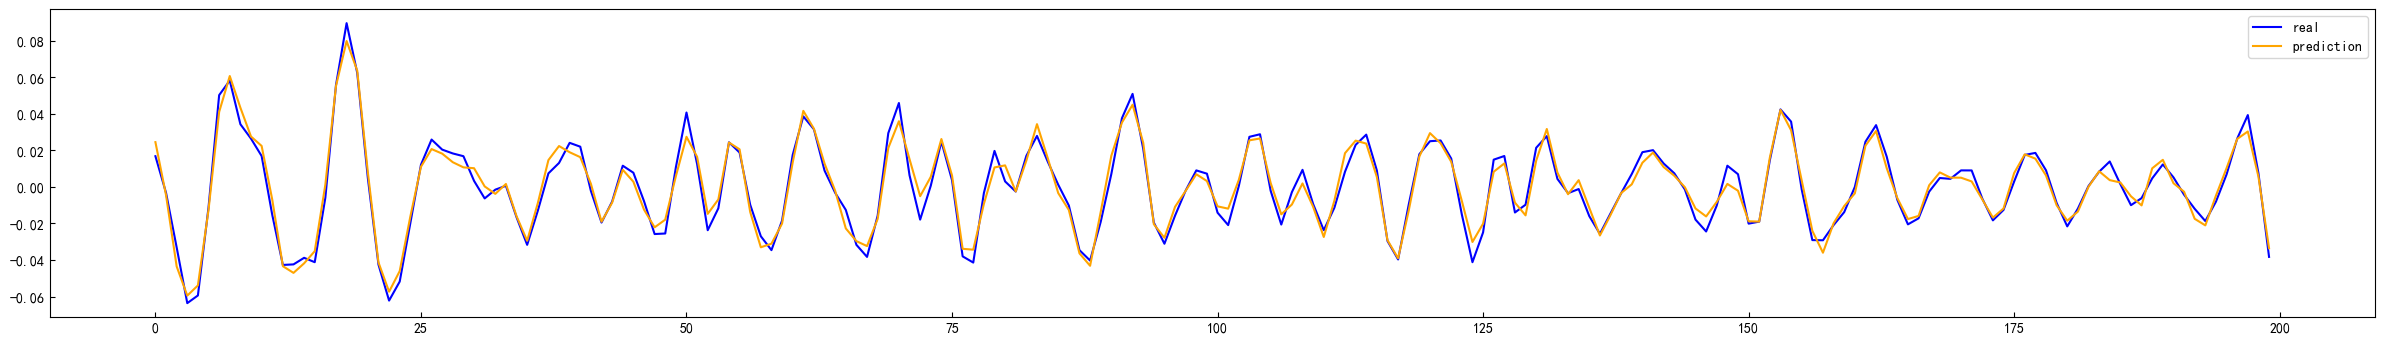

MAE: 0.004061566584763757
MAE(sklearn): 0.004061566584763757
MAPE(sklearn): 0.8396620305471036
MSE: 2.5694552270266504e-05
MSE(sklearn): 2.5694552270266504e-05
RMSE(sklearn): 0.0050689794111109295
Acc: 0.9425557318070272


In [204]:
# 输出1步长pitch
pitch_scaled1 = deal_data2(np.hstack((H,Pitch))[345:,:], 2, 55)
pitch_x1,pitch_y1 = split_sequence(pitch_scaled1, 55)
print(pitch_x1.shape)

train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1 = split_train_valid(pitch_x1,pitch_y1, 7500, 10500)
pit1_model1, pit1_history1, pit1_pre_Y1 = Model_LSTM(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, lr=0.01, epochs=60, batch_size=50)

fan1_pitch_real1,fan1_pitch_pre1 = FanGuiHua_pitch(valid_pit_y1,pit1_pre_Y1)


In [207]:
print(np.hstack((fan1_pitch_real1,fan1_pitch_pre1)))

[[ 0.0168      0.02448825]
 [-0.00323    -0.00453217]
 [-0.0331     -0.04350325]
 ...
 [ 0.0254      0.02439154]
 [ 0.0245      0.02629333]
 [ 0.0143      0.01479262]]


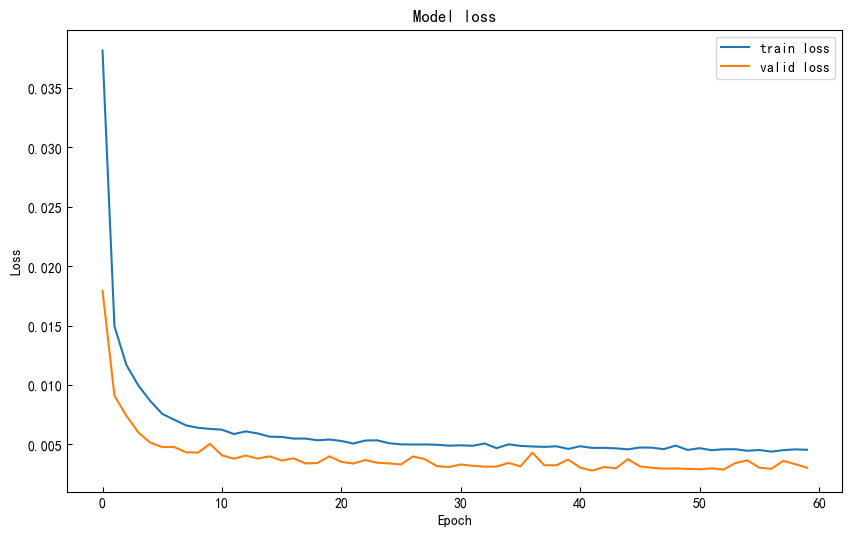

[[0.03816074 0.01793578]
 [0.01494374 0.00909291]
 [0.01168204 0.00740493]
 [0.00995793 0.00599905]
 [0.00864694 0.00513638]
 [0.00756443 0.00476847]
 [0.00707304 0.0047731 ]
 [0.00659136 0.00432912]
 [0.00638842 0.00429743]
 [0.00629764 0.00504152]
 [0.00623105 0.00407374]
 [0.00586447 0.00378726]
 [0.00608547 0.00405349]
 [0.00591105 0.00379873]
 [0.00564424 0.00398315]
 [0.00561894 0.00363655]
 [0.00548127 0.00381704]
 [0.00548129 0.00338862]
 [0.005337   0.00342324]
 [0.00540128 0.0039885 ]
 [0.00527904 0.00352647]
 [0.00506302 0.00337942]
 [0.00531578 0.00367319]
 [0.00533409 0.00344961]
 [0.00508953 0.00339287]
 [0.00499409 0.0033024 ]
 [0.004983   0.00397982]
 [0.0049904  0.00374349]
 [0.00496181 0.00316077]
 [0.00488459 0.00308498]
 [0.00491453 0.00330171]
 [0.00487538 0.00318797]
 [0.00506687 0.00311362]
 [0.00467442 0.00312522]
 [0.0049958  0.00343047]
 [0.00486554 0.00313853]
 [0.00481522 0.00429628]
 [0.00478179 0.00323551]
 [0.00483316 0.0032263 ]
 [0.0046103  0.00371687]


In [208]:
np.savetxt('pitch_步长1(3.2.2).csv',np.hstack((fan1_pitch_real1,fan1_pitch_pre1)),delimiter=',')
loss_plot(pit1_history1, epo=60, length=10, width=6)

(10546, 55, 1)
Epoch 1/60
150/150 - 38s - loss: 0.0296 - val_loss: 0.0226 - 38s/epoch - 253ms/step
Epoch 2/60
150/150 - 33s - loss: 0.0237 - val_loss: 0.0221 - 33s/epoch - 220ms/step
Epoch 3/60
150/150 - 32s - loss: 0.0233 - val_loss: 0.0219 - 32s/epoch - 216ms/step
Epoch 4/60
150/150 - 33s - loss: 0.0227 - val_loss: 0.0214 - 33s/epoch - 217ms/step
Epoch 5/60
150/150 - 33s - loss: 0.0219 - val_loss: 0.0201 - 33s/epoch - 217ms/step
Epoch 6/60
150/150 - 33s - loss: 0.0213 - val_loss: 0.0199 - 33s/epoch - 219ms/step
Epoch 7/60
150/150 - 33s - loss: 0.0213 - val_loss: 0.0199 - 33s/epoch - 217ms/step
Epoch 8/60
150/150 - 33s - loss: 0.0210 - val_loss: 0.0196 - 33s/epoch - 220ms/step
Epoch 9/60
150/150 - 32s - loss: 0.0210 - val_loss: 0.0196 - 32s/epoch - 216ms/step
Epoch 10/60
150/150 - 33s - loss: 0.0209 - val_loss: 0.0195 - 33s/epoch - 217ms/step
Epoch 11/60
150/150 - 32s - loss: 0.0208 - val_loss: 0.0194 - 32s/epoch - 214ms/step
Epoch 12/60
150/150 - 32s - loss: 0.0206 - val_loss: 0.0193

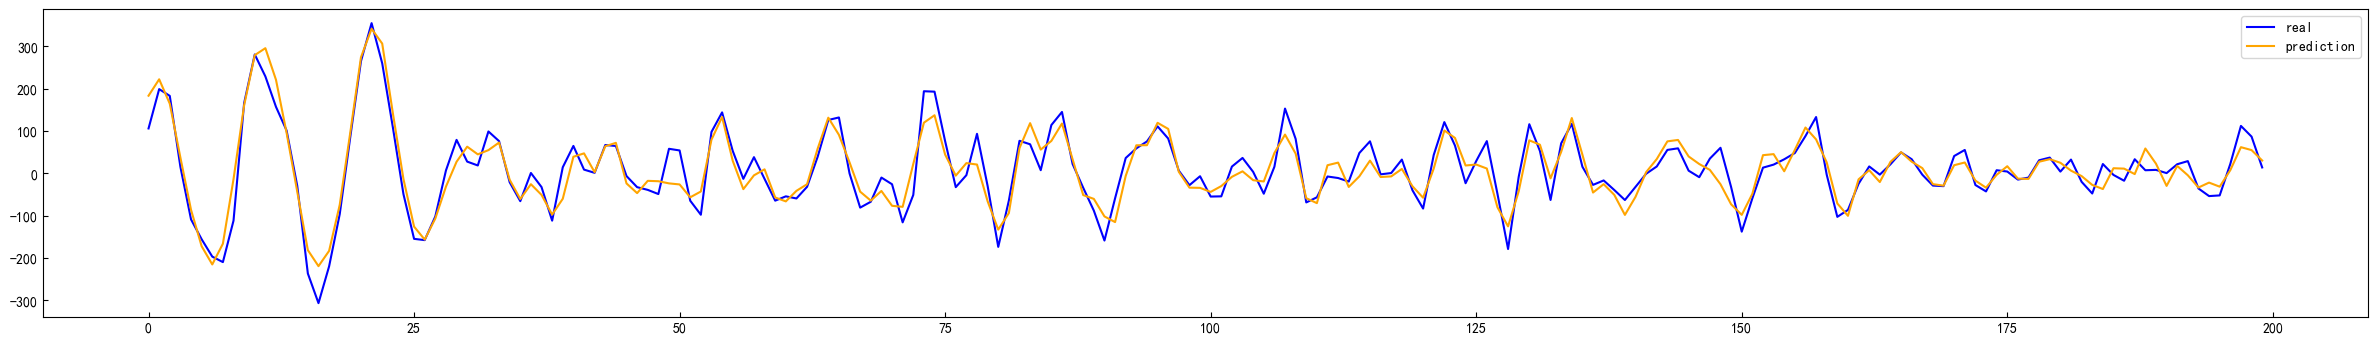

MAE: 26.785339555436035
MAE(sklearn): 26.785339555436035
MAPE(sklearn): 2.4716961597704095
MSE: 1161.5344274530219
MSE(sklearn): 1161.5344274530219
RMSE(sklearn): 34.08129145811558
Acc: 0.9392581620429603


In [205]:
# 输出1步长surge
surge_scaled1 = deal_data2(np.hstack((H,Surge))[345:,:], 2, 55)
surge_x1,surge_y1 = split_sequence(surge_scaled1, 55)
print(surge_x1.shape)

train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1 = split_train_valid(surge_x1,surge_y1, 7500, 10500)
sur1_model1, sur1_history1, sur1_pre_Y1 = Model_LSTM(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, lr=0.01, epochs=60, batch_size=50)

fan1_surge_real1,fan1_surge_pre1 = FanGuiHua_surge(valid_sur_y1,sur1_pre_Y1)

In [209]:
print(np.hstack((fan1_surge_real1,fan1_surge_pre1)))

[[106.         183.40800476]
 [199.         222.23284912]
 [183.         164.4783783 ]
 ...
 [-67.7        -74.28717041]
 [ 17.2         27.0530777 ]
 [ 75.6         69.8221817 ]]


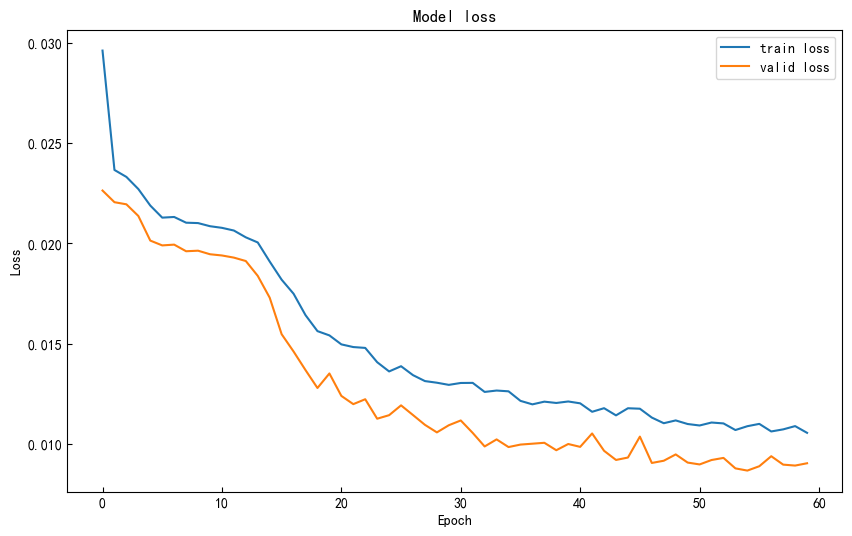

[[0.02961257 0.02263494]
 [0.02366058 0.02205335]
 [0.02331387 0.02194772]
 [0.02270946 0.02136659]
 [0.02188619 0.02013983]
 [0.02128383 0.0198994 ]
 [0.02131673 0.01993809]
 [0.02103166 0.01960828]
 [0.02101245 0.01963575]
 [0.02085633 0.01945839]
 [0.0207752  0.01939754]
 [0.0206409  0.01929051]
 [0.02030156 0.01912055]
 [0.02004587 0.01838028]
 [0.01909541 0.01729257]
 [0.01818987 0.01547246]
 [0.01748897 0.01460866]
 [0.01642148 0.01368227]
 [0.01562566 0.01278955]
 [0.01541246 0.01351476]
 [0.01496513 0.01239614]
 [0.01483113 0.0119853 ]
 [0.01478869 0.01222958]
 [0.01407628 0.01125901]
 [0.01361564 0.01143474]
 [0.0138758  0.01192466]
 [0.01343063 0.01144117]
 [0.01313497 0.01095349]
 [0.01305338 0.01057703]
 [0.01294621 0.01093385]
 [0.01304059 0.01117194]
 [0.01304548 0.01055081]
 [0.01259422 0.0098756 ]
 [0.01266332 0.01022758]
 [0.01262434 0.00984552]
 [0.01214874 0.00996911]
 [0.0119745  0.01001321]
 [0.01210928 0.01005803]
 [0.01204382 0.00968794]
 [0.01211793 0.00999755]


In [210]:
np.savetxt('surge_步长1(3.2.2).csv',np.hstack((fan1_surge_real1,fan1_surge_pre1)),delimiter=',')
loss_plot(sur1_history1, epo=60, length=10, width=6)

(10546, 55, 1)
Epoch 1/60
150/150 - 38s - loss: 0.0220 - val_loss: 0.0083 - 38s/epoch - 252ms/step
Epoch 2/60
150/150 - 33s - loss: 0.0087 - val_loss: 0.0058 - 33s/epoch - 217ms/step
Epoch 3/60
150/150 - 34s - loss: 0.0068 - val_loss: 0.0055 - 34s/epoch - 224ms/step
Epoch 4/60
150/150 - 33s - loss: 0.0059 - val_loss: 0.0032 - 33s/epoch - 217ms/step
Epoch 5/60
150/150 - 33s - loss: 0.0049 - val_loss: 0.0033 - 33s/epoch - 219ms/step
Epoch 6/60
150/150 - 32s - loss: 0.0046 - val_loss: 0.0030 - 32s/epoch - 215ms/step
Epoch 7/60
150/150 - 32s - loss: 0.0043 - val_loss: 0.0030 - 32s/epoch - 214ms/step
Epoch 8/60
150/150 - 32s - loss: 0.0039 - val_loss: 0.0023 - 32s/epoch - 213ms/step
Epoch 9/60
150/150 - 32s - loss: 0.0036 - val_loss: 0.0023 - 32s/epoch - 213ms/step
Epoch 10/60
150/150 - 32s - loss: 0.0033 - val_loss: 0.0018 - 32s/epoch - 212ms/step
Epoch 11/60
150/150 - 33s - loss: 0.0034 - val_loss: 0.0019 - 33s/epoch - 221ms/step
Epoch 12/60
150/150 - 32s - loss: 0.0031 - val_loss: 0.0021

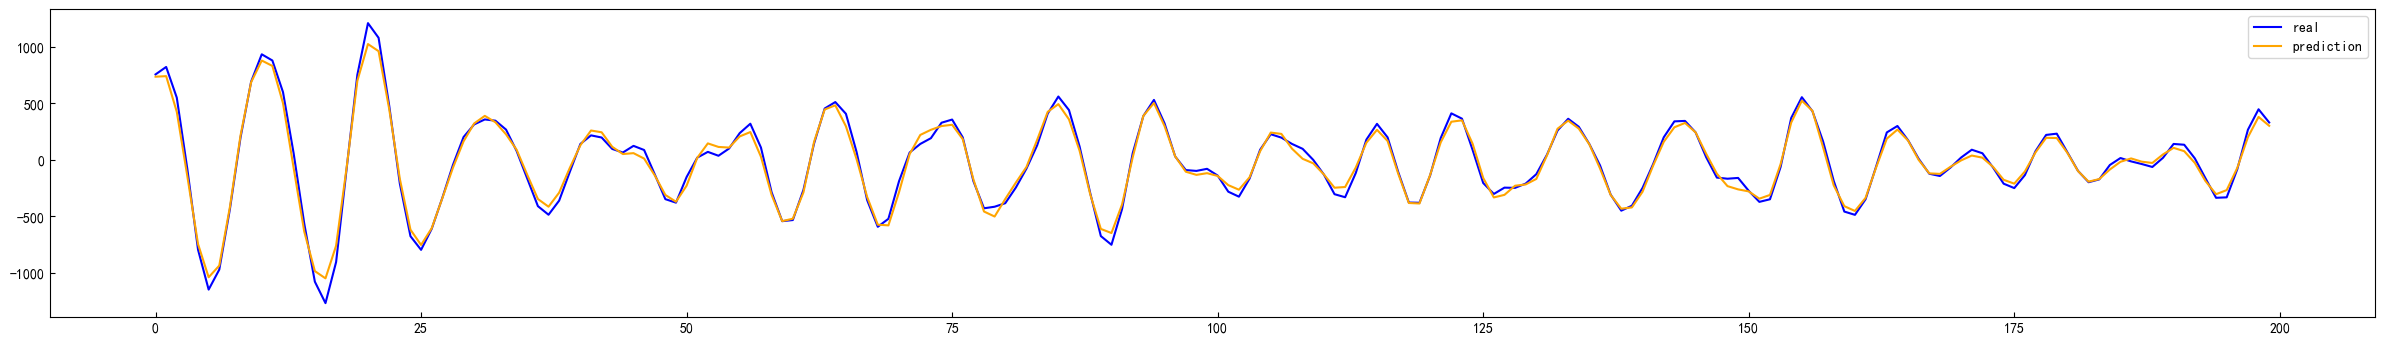

MAE: 37.201616273966124
MAE(sklearn): 37.201616273966124
MAPE(sklearn): 0.9324278690974707
MSE: 2223.5352929628943
MSE(sklearn): 2223.5352929628943
RMSE(sklearn): 47.154377240749284
Acc: 0.9453460930848583


In [206]:
# 输出1步长heave
heave_scaled1 = deal_data2(np.hstack((H,Heave))[345:,:], 2, 55)
heave_x1,heave_y1 = split_sequence(heave_scaled1, 55)
print(heave_x1.shape)

train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1 = split_train_valid(heave_x1,heave_y1, 7500, 10500)
hea1_model1, hea1_history1, hea1_pre_Y1 = Model_LSTM(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, lr=0.01, epochs=60, batch_size=50)

fan1_heave_real1,fan1_heave_pre1 = FanGuiHua_heave(valid_hea_y1,hea1_pre_Y1)

In [211]:
print(np.hstack((fan1_heave_real1,fan1_heave_pre1)))

[[ 756.          735.668396  ]
 [ 822.          740.49761963]
 [ 550.          424.54632568]
 ...
 [-226.         -239.44897461]
 [  81.2          69.25364685]
 [ 338.          313.86865234]]


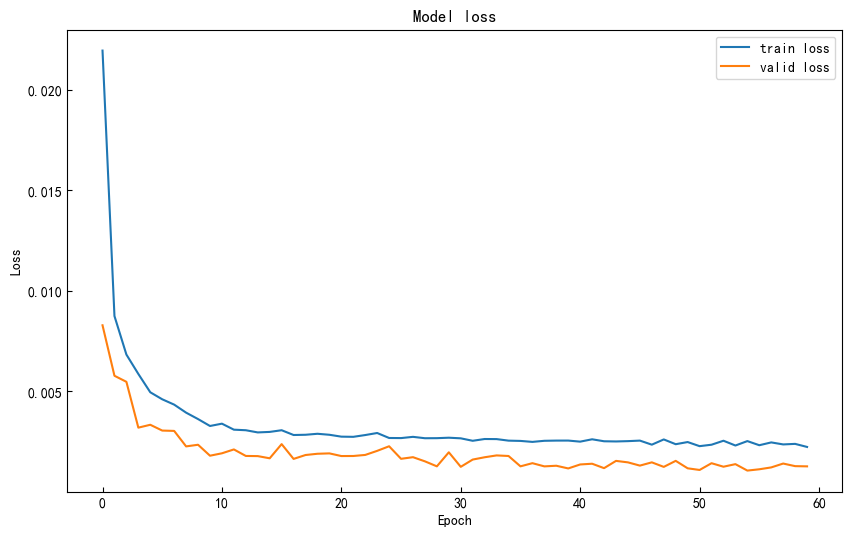

[[0.02196122 0.00828239]
 [0.00874193 0.00576818]
 [0.00682404 0.00546727]
 [0.00585866 0.00318455]
 [0.00494639 0.00332796]
 [0.00459717 0.00303978]
 [0.00433123 0.00302234]
 [0.0039312  0.00225119]
 [0.00361162 0.00233308]
 [0.00326763 0.00178762]
 [0.00338305 0.00190747]
 [0.00308415 0.00209993]
 [0.00305591 0.00177557]
 [0.00294713 0.00176767]
 [0.00297267 0.00165862]
 [0.00305621 0.00236471]
 [0.00281841 0.00162804]
 [0.00283036 0.00182218]
 [0.00287957 0.00188442]
 [0.00283006 0.00190351]
 [0.00273645 0.00177053]
 [0.00272783 0.00177326]
 [0.00281633 0.00182598]
 [0.0029181  0.00202904]
 [0.00266999 0.00225749]
 [0.00266516 0.00163334]
 [0.00272666 0.00171412]
 [0.00265798 0.00150659]
 [0.00266109 0.00125768]
 [0.00268375 0.00195697]
 [0.00265304 0.00123439]
 [0.00253052 0.00159552]
 [0.00261895 0.00171041]
 [0.0026146  0.001802  ]
 [0.00253768 0.00177347]
 [0.00252403 0.00125822]
 [0.0024755  0.00141564]
 [0.00252989 0.00125657]
 [0.00254016 0.00128784]
 [0.00254118 0.00115373]


In [212]:
np.savetxt('heave_步长1(3.2.2).csv',np.hstack((fan1_heave_real1,fan1_heave_pre1)),delimiter=',')
loss_plot(hea1_history1, epo=60, length=10, width=6)

In [179]:
# 不同激活函数下的H-Heave预测
# LSTM
def Model_LSTM_Activation(train_X, train_Y, valid_X, valid_Y, activation='tanh', lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(LSTM(25, activation=activation, return_sequences=True, input_shape=(train_X.shape[1], train_X.shape[2])))  #25×5的数据输入
    model.add(Dropout(0.3))
    model.add(LSTM(100, activation=activation, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(100, activation=activation))
    model.add(Dropout(0.3))
    model.add(Dense(train_Y.shape[1])) 
#     model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

model_sigmoid, history_sigmoid, pre_Y_sigmoid = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='sigmoid', lr=0.01, epochs=60, batch_size=256)
model_tanh, history_tanh, pre_Y_tanh = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.01, epochs=60, batch_size=256)
model_relu, history_relu, pre_Y_relu = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='relu', lr=0.01, epochs=60, batch_size=256)
model_swish, history_swish, pre_Y_swish = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='swish', lr=0.01, epochs=60, batch_size=256)


Epoch 1/60
30/30 - 8s - loss: 0.1803 - val_loss: 0.0761 - 8s/epoch - 270ms/step
Epoch 2/60
30/30 - 5s - loss: 0.1214 - val_loss: 0.0735 - 5s/epoch - 152ms/step
Epoch 3/60
30/30 - 5s - loss: 0.1022 - val_loss: 0.0734 - 5s/epoch - 156ms/step
Epoch 4/60
30/30 - 5s - loss: 0.0913 - val_loss: 0.0734 - 5s/epoch - 154ms/step
Epoch 5/60
30/30 - 5s - loss: 0.0825 - val_loss: 0.0734 - 5s/epoch - 157ms/step
Epoch 6/60
30/30 - 5s - loss: 0.0791 - val_loss: 0.0734 - 5s/epoch - 154ms/step
Epoch 7/60
30/30 - 5s - loss: 0.0769 - val_loss: 0.0734 - 5s/epoch - 154ms/step
Epoch 8/60
30/30 - 5s - loss: 0.0761 - val_loss: 0.0734 - 5s/epoch - 155ms/step
Epoch 9/60
30/30 - 5s - loss: 0.0742 - val_loss: 0.0734 - 5s/epoch - 153ms/step
Epoch 10/60
30/30 - 5s - loss: 0.0740 - val_loss: 0.0734 - 5s/epoch - 157ms/step
Epoch 11/60
30/30 - 5s - loss: 0.0734 - val_loss: 0.0734 - 5s/epoch - 157ms/step
Epoch 12/60
30/30 - 5s - loss: 0.0733 - val_loss: 0.0734 - 5s/epoch - 157ms/step
Epoch 13/60
30/30 - 5s - loss: 0.0732

30/30 - 5s - loss: 0.0030 - val_loss: 0.0019 - 5s/epoch - 179ms/step
Epoch 26/60
30/30 - 5s - loss: 0.0030 - val_loss: 0.0018 - 5s/epoch - 166ms/step
Epoch 27/60
30/30 - 5s - loss: 0.0031 - val_loss: 0.0016 - 5s/epoch - 168ms/step
Epoch 28/60
30/30 - 5s - loss: 0.0029 - val_loss: 0.0018 - 5s/epoch - 159ms/step
Epoch 29/60
30/30 - 5s - loss: 0.0029 - val_loss: 0.0015 - 5s/epoch - 157ms/step
Epoch 30/60
30/30 - 5s - loss: 0.0028 - val_loss: 0.0020 - 5s/epoch - 161ms/step
Epoch 31/60
30/30 - 5s - loss: 0.0030 - val_loss: 0.0015 - 5s/epoch - 164ms/step
Epoch 32/60
30/30 - 5s - loss: 0.0027 - val_loss: 0.0013 - 5s/epoch - 163ms/step
Epoch 33/60
30/30 - 5s - loss: 0.0026 - val_loss: 0.0013 - 5s/epoch - 168ms/step
Epoch 34/60
30/30 - 5s - loss: 0.0026 - val_loss: 0.0017 - 5s/epoch - 165ms/step
Epoch 35/60
30/30 - 5s - loss: 0.0027 - val_loss: 0.0014 - 5s/epoch - 168ms/step
Epoch 36/60
30/30 - 5s - loss: 0.0026 - val_loss: 0.0015 - 5s/epoch - 162ms/step
Epoch 37/60
30/30 - 5s - loss: 0.0025 - 

30/30 - 5s - loss: 0.0085 - val_loss: 0.0075 - 5s/epoch - 165ms/step
Epoch 50/60
30/30 - 5s - loss: 0.0081 - val_loss: 0.0096 - 5s/epoch - 160ms/step
Epoch 51/60
30/30 - 5s - loss: 0.0079 - val_loss: 45.2277 - 5s/epoch - 158ms/step
Epoch 52/60
30/30 - 5s - loss: 136.6989 - val_loss: 0.0170 - 5s/epoch - 161ms/step
Epoch 53/60
30/30 - 5s - loss: 0.0156 - val_loss: 0.0121 - 5s/epoch - 163ms/step
Epoch 54/60
30/30 - 5s - loss: 0.0128 - val_loss: 0.0115 - 5s/epoch - 162ms/step
Epoch 55/60
30/30 - 5s - loss: 0.0115 - val_loss: 0.0134 - 5s/epoch - 163ms/step
Epoch 56/60
30/30 - 5s - loss: 0.0111 - val_loss: 0.0136 - 5s/epoch - 162ms/step
Epoch 57/60
30/30 - 5s - loss: 0.0106 - val_loss: 0.0158 - 5s/epoch - 162ms/step
Epoch 58/60
30/30 - 5s - loss: 0.0104 - val_loss: 0.0156 - 5s/epoch - 163ms/step
Epoch 59/60
30/30 - 5s - loss: 0.0101 - val_loss: 0.0133 - 5s/epoch - 160ms/step
Epoch 60/60
30/30 - 5s - loss: 0.0098 - val_loss: 0.0134 - 5s/epoch - 165ms/step
Model: "sequential_121"
_____________

 dense_122 (Dense)           (None, 1)                 101       
                                                                 
Total params: 133,601
Trainable params: 133,601
Non-trainable params: 0
_________________________________________________________________
94/94 [==============================] - 3s 28ms/step


In [183]:
# 不同激活函数下的H-Surge预测
model_sigmoid2, history_sigmoid2, pre_Y_sigmoid2 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='sigmoid', lr=0.01, epochs=60, batch_size=256)
model_tanh2, history_tanh2, pre_Y_tanh2 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.01, epochs=60, batch_size=256)
model_relu2, history_relu2, pre_Y_relu2 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='relu', lr=0.01, epochs=60, batch_size=256)
model_swish2, history_swish2, pre_Y_swish2 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='swish', lr=0.01, epochs=60, batch_size=256)

Epoch 1/60
30/30 - 8s - loss: 0.1698 - val_loss: 0.0559 - 8s/epoch - 259ms/step
Epoch 2/60
30/30 - 5s - loss: 0.1043 - val_loss: 0.0549 - 5s/epoch - 153ms/step
Epoch 3/60
30/30 - 5s - loss: 0.0809 - val_loss: 0.0550 - 5s/epoch - 152ms/step
Epoch 4/60
30/30 - 5s - loss: 0.0698 - val_loss: 0.0547 - 5s/epoch - 160ms/step
Epoch 5/60
30/30 - 5s - loss: 0.0637 - val_loss: 0.0547 - 5s/epoch - 157ms/step
Epoch 6/60
30/30 - 5s - loss: 0.0602 - val_loss: 0.0547 - 5s/epoch - 156ms/step
Epoch 7/60
30/30 - 5s - loss: 0.0580 - val_loss: 0.0547 - 5s/epoch - 158ms/step
Epoch 8/60
30/30 - 5s - loss: 0.0582 - val_loss: 0.0547 - 5s/epoch - 157ms/step
Epoch 9/60
30/30 - 5s - loss: 0.0569 - val_loss: 0.0547 - 5s/epoch - 158ms/step
Epoch 10/60
30/30 - 5s - loss: 0.0561 - val_loss: 0.0547 - 5s/epoch - 156ms/step
Epoch 11/60
30/30 - 5s - loss: 0.0555 - val_loss: 0.0547 - 5s/epoch - 156ms/step
Epoch 12/60
30/30 - 5s - loss: 0.0558 - val_loss: 0.0547 - 5s/epoch - 159ms/step
Epoch 13/60
30/30 - 5s - loss: 0.0553

30/30 - 5s - loss: 0.0205 - val_loss: 0.0195 - 5s/epoch - 162ms/step
Epoch 26/60
30/30 - 5s - loss: 0.0204 - val_loss: 0.0194 - 5s/epoch - 160ms/step
Epoch 27/60
30/30 - 5s - loss: 0.0202 - val_loss: 0.0194 - 5s/epoch - 155ms/step
Epoch 28/60
30/30 - 5s - loss: 0.0202 - val_loss: 0.0192 - 5s/epoch - 158ms/step
Epoch 29/60
30/30 - 5s - loss: 0.0203 - val_loss: 0.0192 - 5s/epoch - 161ms/step
Epoch 30/60
30/30 - 5s - loss: 0.0201 - val_loss: 0.0191 - 5s/epoch - 158ms/step
Epoch 31/60
30/30 - 5s - loss: 0.0202 - val_loss: 0.0192 - 5s/epoch - 160ms/step
Epoch 32/60
30/30 - 5s - loss: 0.0201 - val_loss: 0.0191 - 5s/epoch - 163ms/step
Epoch 33/60
30/30 - 5s - loss: 0.0198 - val_loss: 0.0189 - 5s/epoch - 158ms/step
Epoch 34/60
30/30 - 5s - loss: 0.0200 - val_loss: 0.0188 - 5s/epoch - 160ms/step
Epoch 35/60
30/30 - 5s - loss: 0.0198 - val_loss: 0.0185 - 5s/epoch - 158ms/step
Epoch 36/60
30/30 - 5s - loss: 0.0195 - val_loss: 0.0182 - 5s/epoch - 161ms/step
Epoch 37/60
30/30 - 5s - loss: 0.0192 - 

30/30 - 5s - loss: 0.0214 - val_loss: 0.0202 - 5s/epoch - 151ms/step
Epoch 50/60
30/30 - 4s - loss: 0.0214 - val_loss: 0.0198 - 4s/epoch - 149ms/step
Epoch 51/60
30/30 - 5s - loss: 0.0210 - val_loss: 0.0201 - 5s/epoch - 158ms/step
Epoch 52/60
30/30 - 5s - loss: 0.0213 - val_loss: 0.0198 - 5s/epoch - 153ms/step
Epoch 53/60
30/30 - 5s - loss: 0.0240 - val_loss: 0.0230 - 5s/epoch - 154ms/step
Epoch 54/60
30/30 - 5s - loss: 0.0238 - val_loss: 0.0209 - 5s/epoch - 153ms/step
Epoch 55/60
30/30 - 5s - loss: 0.0231 - val_loss: 0.0211 - 5s/epoch - 159ms/step
Epoch 56/60
30/30 - 5s - loss: 0.0226 - val_loss: 0.0203 - 5s/epoch - 155ms/step
Epoch 57/60
30/30 - 5s - loss: 0.0224 - val_loss: 0.0202 - 5s/epoch - 156ms/step
Epoch 58/60
30/30 - 5s - loss: 0.0221 - val_loss: 0.0199 - 5s/epoch - 158ms/step
Epoch 59/60
30/30 - 4s - loss: 0.0219 - val_loss: 0.0199 - 4s/epoch - 150ms/step
Epoch 60/60
30/30 - 5s - loss: 0.0219 - val_loss: 0.0198 - 5s/epoch - 158ms/step
Model: "sequential_125"
________________

 dense_126 (Dense)           (None, 1)                 101       
                                                                 
Total params: 133,601
Trainable params: 133,601
Non-trainable params: 0
_________________________________________________________________
94/94 [==============================] - 3s 27ms/step


In [184]:
# 不同激活函数下的H-Pitch预测
model_sigmoid3, history_sigmoid3, pre_Y_sigmoid3 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='sigmoid', lr=0.01, epochs=60, batch_size=256)
model_tanh3, history_tanh3, pre_Y_tanh3 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.01, epochs=60, batch_size=256)
model_relu3, history_relu3, pre_Y_relu3 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='relu', lr=0.01, epochs=60, batch_size=256)
model_swish3, history_swish3, pre_Y_swish3 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='swish', lr=0.01, epochs=60, batch_size=256)

Epoch 1/60
30/30 - 8s - loss: 0.1839 - val_loss: 0.0690 - 8s/epoch - 251ms/step
Epoch 2/60
30/30 - 5s - loss: 0.1245 - val_loss: 0.0701 - 5s/epoch - 150ms/step
Epoch 3/60
30/30 - 4s - loss: 0.1004 - val_loss: 0.0690 - 4s/epoch - 149ms/step
Epoch 4/60
30/30 - 5s - loss: 0.0865 - val_loss: 0.0689 - 5s/epoch - 152ms/step
Epoch 5/60
30/30 - 5s - loss: 0.0785 - val_loss: 0.0690 - 5s/epoch - 151ms/step
Epoch 6/60
30/30 - 5s - loss: 0.0756 - val_loss: 0.0691 - 5s/epoch - 157ms/step
Epoch 7/60
30/30 - 5s - loss: 0.0729 - val_loss: 0.0691 - 5s/epoch - 153ms/step
Epoch 8/60
30/30 - 5s - loss: 0.0720 - val_loss: 0.0690 - 5s/epoch - 154ms/step
Epoch 9/60
30/30 - 5s - loss: 0.0711 - val_loss: 0.0690 - 5s/epoch - 154ms/step
Epoch 10/60
30/30 - 5s - loss: 0.0706 - val_loss: 0.0690 - 5s/epoch - 152ms/step
Epoch 11/60
30/30 - 5s - loss: 0.0705 - val_loss: 0.0691 - 5s/epoch - 154ms/step
Epoch 12/60
30/30 - 5s - loss: 0.0695 - val_loss: 0.0690 - 5s/epoch - 158ms/step
Epoch 13/60
30/30 - 5s - loss: 0.0693

30/30 - 6s - loss: 0.0063 - val_loss: 0.0038 - 6s/epoch - 188ms/step
Epoch 26/60
30/30 - 5s - loss: 0.0064 - val_loss: 0.0044 - 5s/epoch - 174ms/step
Epoch 27/60
30/30 - 5s - loss: 0.0062 - val_loss: 0.0037 - 5s/epoch - 179ms/step
Epoch 28/60
30/30 - 5s - loss: 0.0059 - val_loss: 0.0036 - 5s/epoch - 178ms/step
Epoch 29/60
30/30 - 5s - loss: 0.0059 - val_loss: 0.0037 - 5s/epoch - 174ms/step
Epoch 30/60
30/30 - 5s - loss: 0.0057 - val_loss: 0.0038 - 5s/epoch - 175ms/step
Epoch 31/60
30/30 - 5s - loss: 0.0058 - val_loss: 0.0038 - 5s/epoch - 174ms/step
Epoch 32/60
30/30 - 5s - loss: 0.0056 - val_loss: 0.0039 - 5s/epoch - 175ms/step
Epoch 33/60
30/30 - 5s - loss: 0.0056 - val_loss: 0.0039 - 5s/epoch - 183ms/step
Epoch 34/60
30/30 - 5s - loss: 0.0056 - val_loss: 0.0035 - 5s/epoch - 176ms/step
Epoch 35/60
30/30 - 5s - loss: 0.0054 - val_loss: 0.0037 - 5s/epoch - 179ms/step
Epoch 36/60
30/30 - 5s - loss: 0.0055 - val_loss: 0.0038 - 5s/epoch - 175ms/step
Epoch 37/60
30/30 - 5s - loss: 0.0056 - 

30/30 - 5s - loss: 0.0120 - val_loss: 0.0093 - 5s/epoch - 175ms/step
Epoch 50/60
30/30 - 5s - loss: 0.0119 - val_loss: 0.0086 - 5s/epoch - 175ms/step
Epoch 51/60
30/30 - 5s - loss: 0.0117 - val_loss: 0.0084 - 5s/epoch - 176ms/step
Epoch 52/60
30/30 - 5s - loss: 0.0116 - val_loss: 0.0091 - 5s/epoch - 178ms/step
Epoch 53/60
30/30 - 5s - loss: 0.0117 - val_loss: 0.0112 - 5s/epoch - 176ms/step
Epoch 54/60
30/30 - 5s - loss: 0.0119 - val_loss: 0.0108 - 5s/epoch - 174ms/step
Epoch 55/60
30/30 - 5s - loss: 0.0118 - val_loss: 0.0078 - 5s/epoch - 175ms/step
Epoch 56/60
30/30 - 5s - loss: 0.0115 - val_loss: 0.0076 - 5s/epoch - 174ms/step
Epoch 57/60
30/30 - 5s - loss: 0.0111 - val_loss: 0.0075 - 5s/epoch - 177ms/step
Epoch 58/60
30/30 - 5s - loss: 0.0108 - val_loss: 0.0083 - 5s/epoch - 175ms/step
Epoch 59/60
30/30 - 5s - loss: 0.0110 - val_loss: 0.0097 - 5s/epoch - 175ms/step
Epoch 60/60
30/30 - 5s - loss: 0.0110 - val_loss: 0.0076 - 5s/epoch - 176ms/step
Model: "sequential_129"
________________

 dense_130 (Dense)           (None, 1)                 101       
                                                                 
Total params: 133,601
Trainable params: 133,601
Non-trainable params: 0
_________________________________________________________________
94/94 [==============================] - 3s 32ms/step


In [182]:
print(np.hstack((np.array(history_sigmoid.history['loss']).reshape(60,1), np.array(history_sigmoid.history['val_loss']).reshape(60,1))))
print(np.hstack((np.array(history_tanh.history['loss']).reshape(60,1), np.array(history_tanh.history['val_loss']).reshape(60,1))))
print(np.hstack((np.array(history_relu.history['loss']).reshape(60,1), np.array(history_relu.history['val_loss']).reshape(60,1))))
print(np.hstack((np.array(history_swish.history['loss']).reshape(60,1), np.array(history_swish.history['val_loss']).reshape(60,1))))

# def evaluate_Ac(valid_y,pre_Y):
#     XP1 = valid_y.copy
#     XA1 = pre_Y.copy
#     pre1 = np.trapz(abs((XP1 - (XP1.sum()/(XP1.shape[0])))).reshape(XP1.shape[0],), dx=0.1)
#     real1 = np.trapz(abs((XA1 - (XA1.sum()/(XA1.shape[0])))).reshape(XA1.shape[0],), dx=0.1)
#     Acc1 = 1 - abs(1 - (pre1/real1))
#     return Acc1

# total_loss_Act1, Acc_Act1 = evaluate_Ac(valid_hea_y1, pre_Y_sigmoid)
# total_loss_Act2, Acc_Act2 = evaluate_Ac(valid_hea_y1, pre_Y_tanh)
# total_loss_Act3, Acc_Act3 = evaluate_Ac(valid_hea_y1, pre_Y_relu)
# total_loss_Act4, Acc_Act4 = evaluate_Ac(valid_hea_y1, pre_Y_swish)

[[0.18026294 0.07606942]
 [0.12140185 0.07347877]
 [0.10219444 0.07339475]
 [0.09128338 0.0734311 ]
 [0.08252816 0.07339372]
 [0.07911371 0.07340985]
 [0.07691542 0.07340252]
 [0.07607245 0.07339597]
 [0.07422025 0.07338744]
 [0.07399342 0.0733898 ]
 [0.07335208 0.0733906 ]
 [0.07333466 0.07339536]
 [0.07322316 0.07339993]
 [0.07289696 0.0733982 ]
 [0.07260329 0.07339124]
 [0.07277862 0.07339025]
 [0.07261708 0.07339473]
 [0.07264367 0.0733918 ]
 [0.07224744 0.07341548]
 [0.07237642 0.07338862]
 [0.07220148 0.07339464]
 [0.07236487 0.07338629]
 [0.07206273 0.07338914]
 [0.07205518 0.07338479]
 [0.072028   0.07338263]
 [0.07205909 0.07340448]
 [0.07215355 0.07337409]
 [0.07198916 0.07337045]
 [0.07201461 0.07341967]
 [0.07172139 0.07337234]
 [0.07193929 0.07337762]
 [0.0718884  0.0733579 ]
 [0.07186706 0.07333129]
 [0.07193595 0.07332781]
 [0.07172436 0.0733158 ]
 [0.07153559 0.07327637]
 [0.07168102 0.07324442]
 [0.0716961  0.0732104 ]
 [0.07149835 0.07316669]
 [0.07159982 0.07309713]


In [185]:
# 不同学习率下的H-Heave预测
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
def evaluate_lr(valid_y,pre_Y):
    XP1 = valid_y.copy()
    XA1 = pre_Y.copy()
    pre1 = np.trapz(abs((XP1 - (XP1.sum()/(XP1.shape[0])))).reshape(XP1.shape[0],), dx=0.1)
    real1 = np.trapz(abs((XA1 - (XA1.sum()/(XA1.shape[0])))).reshape(XA1.shape[0],), dx=0.1)
    Acc1 = 1 - abs(1 - (pre1/real1))
    return Acc1

In [186]:
model_lr1, history_lr1, pre_Y_lr1 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0, epochs=10, batch_size=56)
model_lr2, history_lr2, pre_Y_lr2 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.05, epochs=10, batch_size=56)
model_lr3, history_lr3, pre_Y_lr3 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.08, epochs=10, batch_size=56)
model_lr4, history_lr4, pre_Y_lr4 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.1, epochs=10, batch_size=56)
model_lr5, history_lr5, pre_Y_lr5 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.15, epochs=10, batch_size=56)
model_lr6, history_lr6, pre_Y_lr6 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.2, epochs=10, batch_size=56)
model_lr7, history_lr7, pre_Y_lr7 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.25, epochs=10, batch_size=56)
model_lr8, history_lr8, pre_Y_lr8 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.3, epochs=10, batch_size=56)
model_lr9, history_lr9, pre_Y_lr9 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.35, epochs=10, batch_size=56)
model_lr10, history_lr10, pre_Y_lr10 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.4, epochs=10, batch_size=56)
model_lr11, history_lr11, pre_Y_lr11 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.45, epochs=10, batch_size=56)
model_lr12, history_lr12, pre_Y_lr12 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.5, epochs=10, batch_size=56)
model_lr13, history_lr13, pre_Y_lr13 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.55, epochs=10, batch_size=56)
model_lr14, history_lr14, pre_Y_lr14 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.6, epochs=10, batch_size=56)
model_lr15, history_lr15, pre_Y_lr15 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.65, epochs=10, batch_size=56)
model_lr16, history_lr16, pre_Y_lr16 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.7, epochs=10, batch_size=56)
model_lr17, history_lr17, pre_Y_lr17 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.75, epochs=10, batch_size=56)
model_lr18, history_lr18, pre_Y_lr18 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.8, epochs=10, batch_size=56)
model_lr19, history_lr19, pre_Y_lr19 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.85, epochs=10, batch_size=56)
model_lr20, history_lr20, pre_Y_lr20 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.9, epochs=10, batch_size=56)
model_lr21, history_lr21, pre_Y_lr21 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.95, epochs=10, batch_size=56)


Epoch 1/10
134/134 - 29s - loss: 0.0232 - val_loss: 0.0099 - 29s/epoch - 216ms/step
Epoch 2/10
134/134 - 14s - loss: 0.0092 - val_loss: 0.0061 - 14s/epoch - 107ms/step
Epoch 3/10
134/134 - 14s - loss: 0.0075 - val_loss: 0.0043 - 14s/epoch - 107ms/step
Epoch 4/10
134/134 - 14s - loss: 0.0059 - val_loss: 0.0037 - 14s/epoch - 106ms/step
Epoch 5/10
134/134 - 14s - loss: 0.0052 - val_loss: 0.0030 - 14s/epoch - 106ms/step
Epoch 6/10
134/134 - 14s - loss: 0.0047 - val_loss: 0.0026 - 14s/epoch - 107ms/step
Epoch 7/10
134/134 - 14s - loss: 0.0043 - val_loss: 0.0026 - 14s/epoch - 107ms/step
Epoch 8/10
134/134 - 14s - loss: 0.0041 - val_loss: 0.0022 - 14s/epoch - 107ms/step
Epoch 9/10
134/134 - 14s - loss: 0.0037 - val_loss: 0.0019 - 14s/epoch - 107ms/step
Epoch 10/10
134/134 - 14s - loss: 0.0033 - val_loss: 0.0016 - 14s/epoch - 105ms/step
Model: "sequential_131"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 ls

                                                                 
 lstm_404 (LSTM)             (None, 100)               80400     
                                                                 
 dropout_404 (Dropout)       (None, 100)               0         
                                                                 
 dense_134 (Dense)           (None, 1)                 101       
                                                                 
Total params: 133,601
Trainable params: 133,601
Non-trainable params: 0
_________________________________________________________________
94/94 [==============================] - 3s 25ms/step
Epoch 1/10
134/134 - 16s - loss: 0.0232 - val_loss: 0.0088 - 16s/epoch - 123ms/step
Epoch 2/10
134/134 - 12s - loss: 0.0094 - val_loss: 0.0061 - 12s/epoch - 88ms/step
Epoch 3/10
134/134 - 11s - loss: 0.0072 - val_loss: 0.0036 - 11s/epoch - 84ms/step
Epoch 4/10
134/134 - 11s - loss: 0.0059 - val_loss: 0.0038 - 11s/epoch - 84ms/step
Epoch 5/10
13

Model: "sequential_138"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_414 (LSTM)             (None, 55, 25)            2700      
                                                                 
 dropout_414 (Dropout)       (None, 55, 25)            0         
                                                                 
 lstm_415 (LSTM)             (None, 55, 100)           50400     
                                                                 
 dropout_415 (Dropout)       (None, 55, 100)           0         
                                                                 
 lstm_416 (LSTM)             (None, 100)               80400     
                                                                 
 dropout_416 (Dropout)       (None, 100)               0         
                                                                 
 dense_138 (Dense)           (None, 1)              

Epoch 2/10
134/134 - 12s - loss: 0.0097 - val_loss: 0.0062 - 12s/epoch - 87ms/step
Epoch 3/10
134/134 - 11s - loss: 0.0077 - val_loss: 0.0044 - 11s/epoch - 85ms/step
Epoch 4/10
134/134 - 11s - loss: 0.0060 - val_loss: 0.0034 - 11s/epoch - 84ms/step
Epoch 5/10
134/134 - 11s - loss: 0.0050 - val_loss: 0.0029 - 11s/epoch - 85ms/step
Epoch 6/10
134/134 - 11s - loss: 0.0049 - val_loss: 0.0028 - 11s/epoch - 85ms/step
Epoch 7/10
134/134 - 11s - loss: 0.0042 - val_loss: 0.0026 - 11s/epoch - 85ms/step
Epoch 8/10
134/134 - 12s - loss: 0.0037 - val_loss: 0.0019 - 12s/epoch - 88ms/step
Epoch 9/10
134/134 - 12s - loss: 0.0036 - val_loss: 0.0017 - 12s/epoch - 86ms/step
Epoch 10/10
134/134 - 11s - loss: 0.0033 - val_loss: 0.0021 - 11s/epoch - 85ms/step
Model: "sequential_142"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_426 (LSTM)             (None, 55, 25)            2700      
                              

 lstm_437 (LSTM)             (None, 100)               80400     
                                                                 
 dropout_437 (Dropout)       (None, 100)               0         
                                                                 
 dense_145 (Dense)           (None, 1)                 101       
                                                                 
Total params: 133,601
Trainable params: 133,601
Non-trainable params: 0
_________________________________________________________________
94/94 [==============================] - 3s 22ms/step
Epoch 1/10
134/134 - 16s - loss: 0.0244 - val_loss: 0.0087 - 16s/epoch - 118ms/step
Epoch 2/10
134/134 - 11s - loss: 0.0090 - val_loss: 0.0057 - 11s/epoch - 83ms/step
Epoch 3/10
134/134 - 11s - loss: 0.0068 - val_loss: 0.0040 - 11s/epoch - 82ms/step
Epoch 4/10
134/134 - 11s - loss: 0.0060 - val_loss: 0.0031 - 11s/epoch - 85ms/step
Epoch 5/10
134/134 - 11s - loss: 0.0052 - val_loss: 0.0028 - 11s/epoch - 83ms/s

Model: "sequential_149"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_447 (LSTM)             (None, 55, 25)            2700      
                                                                 
 dropout_447 (Dropout)       (None, 55, 25)            0         
                                                                 
 lstm_448 (LSTM)             (None, 55, 100)           50400     
                                                                 
 dropout_448 (Dropout)       (None, 55, 100)           0         
                                                                 
 lstm_449 (LSTM)             (None, 100)               80400     
                                                                 
 dropout_449 (Dropout)       (None, 100)               0         
                                                                 
 dense_149 (Dense)           (None, 1)              

In [187]:
model_lr22, history_lr22, pre_Y_lr22 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1, epochs=10, batch_size=56)
model_lr23, history_lr23, pre_Y_lr23 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.05, epochs=10, batch_size=56)
model_lr24, history_lr24, pre_Y_lr24 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.1, epochs=10, batch_size=56)
model_lr25, history_lr25, pre_Y_lr25 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.15, epochs=10, batch_size=56)
model_lr26, history_lr26, pre_Y_lr26 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.2, epochs=10, batch_size=56)
model_lr27, history_lr27, pre_Y_lr27 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.25, epochs=10, batch_size=56)
model_lr28, history_lr28, pre_Y_lr28 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.3, epochs=10, batch_size=56)
model_lr29, history_lr29, pre_Y_lr29 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.35, epochs=10, batch_size=56)
model_lr30, history_lr30, pre_Y_lr30 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.4, epochs=10, batch_size=56)
model_lr31, history_lr31, pre_Y_lr31 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.45, epochs=10, batch_size=56)
model_lr32, history_lr32, pre_Y_lr32 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.5, epochs=10, batch_size=56)
model_lr33, history_lr33, pre_Y_lr33 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.55, epochs=10, batch_size=56)
model_lr34, history_lr34, pre_Y_lr34 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.6, epochs=10, batch_size=56)
model_lr35, history_lr35, pre_Y_lr35 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.65, epochs=10, batch_size=56)
model_lr36, history_lr36, pre_Y_lr36 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.7, epochs=10, batch_size=56)
model_lr37, history_lr37, pre_Y_lr37 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.75, epochs=10, batch_size=56)
model_lr38, history_lr38, pre_Y_lr38 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.8, epochs=10, batch_size=56)
model_lr39, history_lr39, pre_Y_lr39 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.85, epochs=10, batch_size=56)
model_lr40, history_lr40, pre_Y_lr40 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.9, epochs=10, batch_size=56)
model_lr41, history_lr41, pre_Y_lr41 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.95, epochs=10, batch_size=56)
model_lr42, history_lr42, pre_Y_lr42 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=2, epochs=10, batch_size=56)

Epoch 1/10
134/134 - 16s - loss: 0.0236 - val_loss: 0.0086 - 16s/epoch - 120ms/step
Epoch 2/10
134/134 - 12s - loss: 0.0097 - val_loss: 0.0062 - 12s/epoch - 87ms/step
Epoch 3/10
134/134 - 11s - loss: 0.0078 - val_loss: 0.0047 - 11s/epoch - 85ms/step
Epoch 4/10
134/134 - 11s - loss: 0.0061 - val_loss: 0.0037 - 11s/epoch - 85ms/step
Epoch 5/10
134/134 - 11s - loss: 0.0056 - val_loss: 0.0034 - 11s/epoch - 85ms/step
Epoch 6/10
134/134 - 12s - loss: 0.0051 - val_loss: 0.0028 - 12s/epoch - 86ms/step
Epoch 7/10
134/134 - 12s - loss: 0.0049 - val_loss: 0.0032 - 12s/epoch - 87ms/step
Epoch 8/10
134/134 - 12s - loss: 0.0045 - val_loss: 0.0028 - 12s/epoch - 87ms/step
Epoch 9/10
134/134 - 11s - loss: 0.0041 - val_loss: 0.0022 - 11s/epoch - 86ms/step
Epoch 10/10
134/134 - 12s - loss: 0.0039 - val_loss: 0.0021 - 12s/epoch - 86ms/step
Model: "sequential_152"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_456 (L

                                                                 
 lstm_467 (LSTM)             (None, 100)               80400     
                                                                 
 dropout_467 (Dropout)       (None, 100)               0         
                                                                 
 dense_155 (Dense)           (None, 1)                 101       
                                                                 
Total params: 133,601
Trainable params: 133,601
Non-trainable params: 0
_________________________________________________________________
94/94 [==============================] - 3s 22ms/step
Epoch 1/10
134/134 - 16s - loss: 0.0241 - val_loss: 0.0083 - 16s/epoch - 122ms/step
Epoch 2/10
134/134 - 11s - loss: 0.0094 - val_loss: 0.0064 - 11s/epoch - 86ms/step
Epoch 3/10
134/134 - 12s - loss: 0.0074 - val_loss: 0.0041 - 12s/epoch - 86ms/step
Epoch 4/10
134/134 - 12s - loss: 0.0063 - val_loss: 0.0039 - 12s/epoch - 91ms/step
Epoch 5/10
13

Model: "sequential_159"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_477 (LSTM)             (None, 55, 25)            2700      
                                                                 
 dropout_477 (Dropout)       (None, 55, 25)            0         
                                                                 
 lstm_478 (LSTM)             (None, 55, 100)           50400     
                                                                 
 dropout_478 (Dropout)       (None, 55, 100)           0         
                                                                 
 lstm_479 (LSTM)             (None, 100)               80400     
                                                                 
 dropout_479 (Dropout)       (None, 100)               0         
                                                                 
 dense_159 (Dense)           (None, 1)              

Epoch 2/10
134/134 - 11s - loss: 0.0090 - val_loss: 0.0058 - 11s/epoch - 84ms/step
Epoch 3/10
134/134 - 12s - loss: 0.0072 - val_loss: 0.0036 - 12s/epoch - 86ms/step
Epoch 4/10
134/134 - 11s - loss: 0.0057 - val_loss: 0.0031 - 11s/epoch - 84ms/step
Epoch 5/10
134/134 - 12s - loss: 0.0053 - val_loss: 0.0028 - 12s/epoch - 87ms/step
Epoch 6/10
134/134 - 12s - loss: 0.0051 - val_loss: 0.0028 - 12s/epoch - 88ms/step
Epoch 7/10
134/134 - 11s - loss: 0.0045 - val_loss: 0.0032 - 11s/epoch - 84ms/step
Epoch 8/10
134/134 - 11s - loss: 0.0040 - val_loss: 0.0027 - 11s/epoch - 85ms/step
Epoch 9/10
134/134 - 11s - loss: 0.0039 - val_loss: 0.0024 - 11s/epoch - 85ms/step
Epoch 10/10
134/134 - 11s - loss: 0.0035 - val_loss: 0.0019 - 11s/epoch - 85ms/step
Model: "sequential_163"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_489 (LSTM)             (None, 55, 25)            2700      
                              

 lstm_500 (LSTM)             (None, 100)               80400     
                                                                 
 dropout_500 (Dropout)       (None, 100)               0         
                                                                 
 dense_166 (Dense)           (None, 1)                 101       
                                                                 
Total params: 133,601
Trainable params: 133,601
Non-trainable params: 0
_________________________________________________________________
94/94 [==============================] - 14s 22ms/step
Epoch 1/10
134/134 - 16s - loss: 0.0234 - val_loss: 0.0082 - 16s/epoch - 119ms/step
Epoch 2/10
134/134 - 11s - loss: 0.0092 - val_loss: 0.0057 - 11s/epoch - 84ms/step
Epoch 3/10
134/134 - 11s - loss: 0.0073 - val_loss: 0.0041 - 11s/epoch - 85ms/step
Epoch 4/10
134/134 - 12s - loss: 0.0060 - val_loss: 0.0038 - 12s/epoch - 86ms/step
Epoch 5/10
134/134 - 12s - loss: 0.0052 - val_loss: 0.0033 - 12s/epoch - 88ms/

Model: "sequential_170"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_510 (LSTM)             (None, 55, 25)            2700      
                                                                 
 dropout_510 (Dropout)       (None, 55, 25)            0         
                                                                 
 lstm_511 (LSTM)             (None, 55, 100)           50400     
                                                                 
 dropout_511 (Dropout)       (None, 55, 100)           0         
                                                                 
 lstm_512 (LSTM)             (None, 100)               80400     
                                                                 
 dropout_512 (Dropout)       (None, 100)               0         
                                                                 
 dense_170 (Dense)           (None, 1)              

In [189]:
def lr_infor(history_loss, valid_hea_y, pre_Y_lr):
    total_loss = np.hstack((np.array(history_loss.history['loss']).reshape(10,1), np.array(history_loss.history['val_loss']).reshape(10,1)))
    Acc = evaluate_lr(valid_hea_y,pre_Y_lr)
    return total_loss, Acc

total_loss1, Acc1 = lr_infor(history_lr1, valid_hea_y1, pre_Y_lr1)
total_loss2, Acc2 = lr_infor(history_lr2, valid_hea_y1, pre_Y_lr2)
total_loss3, Acc3 = lr_infor(history_lr3, valid_hea_y1, pre_Y_lr3)
total_loss4, Acc4 = lr_infor(history_lr4, valid_hea_y1, pre_Y_lr4)
total_loss5, Acc5 = lr_infor(history_lr5, valid_hea_y1, pre_Y_lr5)
total_loss6, Acc6 = lr_infor(history_lr6, valid_hea_y1, pre_Y_lr6)
total_loss7, Acc7 = lr_infor(history_lr7, valid_hea_y1, pre_Y_lr7)
total_loss8, Acc8 = lr_infor(history_lr8, valid_hea_y1, pre_Y_lr8)
total_loss9, Acc9 = lr_infor(history_lr9, valid_hea_y1, pre_Y_lr9)
total_loss10, Acc10 = lr_infor(history_lr10, valid_hea_y1, pre_Y_lr10)
total_loss11, Acc11 = lr_infor(history_lr11, valid_hea_y1, pre_Y_lr11)
total_loss12, Acc12 = lr_infor(history_lr12, valid_hea_y1, pre_Y_lr12)
total_loss13, Acc13 = lr_infor(history_lr13, valid_hea_y1, pre_Y_lr13)
total_loss14, Acc14 = lr_infor(history_lr14, valid_hea_y1, pre_Y_lr14)
total_loss15, Acc15 = lr_infor(history_lr15, valid_hea_y1, pre_Y_lr15)
total_loss16, Acc16 = lr_infor(history_lr16, valid_hea_y1, pre_Y_lr16)
total_loss17, Acc17 = lr_infor(history_lr17, valid_hea_y1, pre_Y_lr17)
total_loss18, Acc18 = lr_infor(history_lr18, valid_hea_y1, pre_Y_lr18)
total_loss19, Acc19 = lr_infor(history_lr19, valid_hea_y1, pre_Y_lr19)
total_loss20, Acc20 = lr_infor(history_lr20, valid_hea_y1, pre_Y_lr20)
total_loss21, Acc21 = lr_infor(history_lr31, valid_hea_y1, pre_Y_lr21)
total_loss22, Acc22 = lr_infor(history_lr32, valid_hea_y1, pre_Y_lr22)
total_loss23, Acc23 = lr_infor(history_lr35, valid_hea_y1, pre_Y_lr23)
total_loss24, Acc24 = lr_infor(history_lr34, valid_hea_y1, pre_Y_lr24)
total_loss25, Acc25 = lr_infor(history_lr35, valid_hea_y1, pre_Y_lr25)
total_loss26, Acc26 = lr_infor(history_lr36, valid_hea_y1, pre_Y_lr26)
total_loss27, Acc27 = lr_infor(history_lr37, valid_hea_y1, pre_Y_lr27)
total_loss28, Acc28 = lr_infor(history_lr38, valid_hea_y1, pre_Y_lr28)
total_loss29, Acc29 = lr_infor(history_lr39, valid_hea_y1, pre_Y_lr29)
total_loss30, Acc30 = lr_infor(history_lr40, valid_hea_y1, pre_Y_lr30)
total_loss31, Acc31 = lr_infor(history_lr31, valid_hea_y1, pre_Y_lr31)
total_loss32, Acc32 = lr_infor(history_lr32, valid_hea_y1, pre_Y_lr32)
total_loss33, Acc33 = lr_infor(history_lr35, valid_hea_y1, pre_Y_lr33)
total_loss34, Acc34 = lr_infor(history_lr34, valid_hea_y1, pre_Y_lr34)
total_loss35, Acc35 = lr_infor(history_lr35, valid_hea_y1, pre_Y_lr35)
total_loss36, Acc36 = lr_infor(history_lr36, valid_hea_y1, pre_Y_lr36)
total_loss37, Acc37 = lr_infor(history_lr37, valid_hea_y1, pre_Y_lr37)
total_loss38, Acc38 = lr_infor(history_lr38, valid_hea_y1, pre_Y_lr38)
total_loss39, Acc39 = lr_infor(history_lr39, valid_hea_y1, pre_Y_lr39)
total_loss40, Acc40 = lr_infor(history_lr40, valid_hea_y1, pre_Y_lr40)
total_loss41, Acc41 = lr_infor(history_lr41, valid_hea_y1, pre_Y_lr41)
total_loss42, Acc42 = lr_infor(history_lr42, valid_hea_y1, pre_Y_lr42)

print(total_loss1, Acc1)
print(total_loss2, Acc2)
print(total_loss3, Acc3)
print(total_loss4, Acc4)
print(total_loss5, Acc5)
print(total_loss6, Acc6)
print(total_loss7, Acc7)
print(total_loss8, Acc8)
print(total_loss9, Acc9)
print(total_loss10, Acc10)
print(total_loss11, Acc11)
print(total_loss12, Acc12)
print(total_loss13, Acc13)
print(total_loss14, Acc14)
print(total_loss15, Acc15)
print(total_loss16, Acc16)
print(total_loss17, Acc17)
print(total_loss18, Acc18)
print(total_loss19, Acc19)
print(total_loss20, Acc20)
print(total_loss21, Acc21)
print(total_loss22, Acc22)
print(total_loss23, Acc23)
print(total_loss24, Acc24)
print(total_loss25, Acc25)
print(total_loss26, Acc26)
print(total_loss27, Acc27)
print(total_loss28, Acc28)
print(total_loss29, Acc29)
print(total_loss30, Acc30)
print(total_loss31, Acc31)
print(total_loss32, Acc32)
print(total_loss33, Acc33)
print(total_loss34, Acc34)
print(total_loss35, Acc35)
print(total_loss36, Acc36)
print(total_loss37, Acc37)
print(total_loss38, Acc38)
print(total_loss39, Acc39)
print(total_loss40, Acc40)
print(total_loss41, Acc41)
print(total_loss42, Acc42)

[[0.02322779 0.00992244]
 [0.00924677 0.00613425]
 [0.00752007 0.00434581]
 [0.00587071 0.00365802]
 [0.00522921 0.00301958]
 [0.00471356 0.00261255]
 [0.00429499 0.00264356]
 [0.00405058 0.00219693]
 [0.00372334 0.00194874]
 [0.00332202 0.00156391]] 0.9969169843915584
[[0.02211407 0.0087336 ]
 [0.00912538 0.0059981 ]
 [0.00713911 0.00607061]
 [0.00566693 0.00317265]
 [0.00515877 0.00324077]
 [0.00503089 0.00276083]
 [0.00466894 0.00238407]
 [0.0041898  0.00230242]
 [0.00389258 0.00348083]
 [0.0036092  0.00191554]] 0.9631020522798588
[[0.02395852 0.0087831 ]
 [0.0093988  0.00672049]
 [0.00740125 0.00386194]
 [0.00595647 0.00453353]
 [0.00524155 0.00325353]
 [0.00500521 0.0027068 ]
 [0.00456287 0.00243581]
 [0.00395389 0.00207845]
 [0.00361314 0.00318014]
 [0.00355042 0.00271362]] 0.8687862312307024
[[0.0241918  0.0089192 ]
 [0.00960138 0.0066441 ]
 [0.00748398 0.0058874 ]
 [0.00618562 0.00430745]
 [0.00552667 0.00301705]
 [0.00493404 0.0025387 ]
 [0.00495802 0.00287493]
 [0.0041564  0.

In [190]:
Act1 = [Acc1, Acc2, Acc3, Acc4, Acc5, Acc6, Acc7, 
       Acc8, Acc9, Acc10, Acc11, Acc12, Acc13, Acc14, 
       Acc15, Acc16, Acc17, Acc18, Acc19, Acc20, Acc21, 
       Acc22, Acc23, Acc24, Acc25, Acc26, Acc27, Acc28, 
       Acc29, Acc30, Acc31, Acc32, Acc33, Acc34, Acc35, 
       Acc36, Acc37, Acc38, Acc39, Acc40, Acc41, Acc42]

In [193]:
print(np.array((Act1)).reshape(42,1))

[[0.99691698]
 [0.96310205]
 [0.86878623]
 [0.99555948]
 [0.9771875 ]
 [0.98904036]
 [0.97341401]
 [0.98958957]
 [0.96341231]
 [0.96033715]
 [0.91634235]
 [0.91863799]
 [0.86387621]
 [0.91340215]
 [0.97168396]
 [0.97647671]
 [0.93676622]
 [0.9344904 ]
 [0.95264275]
 [0.94862947]
 [0.99582444]
 [0.97163053]
 [0.91431659]
 [0.94027745]
 [0.99034357]
 [0.93628612]
 [0.95899006]
 [0.90177203]
 [0.92760384]
 [0.97576594]
 [0.992051  ]
 [0.97989013]
 [0.95500169]
 [0.97885018]
 [0.92040821]
 [0.96754822]
 [0.95655415]
 [0.96239558]
 [0.95840753]
 [0.94451232]
 [0.94711508]
 [0.98082431]]


In [ ]:
model_lr1, history_lr1, pre_Y_lr1 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0, epochs=10, batch_size=56)
model_lr2, history_lr2, pre_Y_lr2 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.05, epochs=10, batch_size=56)
model_lr3, history_lr3, pre_Y_lr3 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.08, epochs=10, batch_size=56)
model_lr4, history_lr4, pre_Y_lr4 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.1, epochs=10, batch_size=56)
model_lr5, history_lr5, pre_Y_lr5 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.15, epochs=10, batch_size=56)
model_lr6, history_lr6, pre_Y_lr6 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.2, epochs=10, batch_size=56)


Epoch 1/10
134/134 - 16s - loss: 0.0307 - val_loss: 0.0227 - 16s/epoch - 118ms/step
Epoch 2/10
134/134 - 13s - loss: 0.0240 - val_loss: 0.0222 - 13s/epoch - 100ms/step
Epoch 3/10
134/134 - 13s - loss: 0.0232 - val_loss: 0.0219 - 13s/epoch - 97ms/step
Epoch 4/10
134/134 - 12s - loss: 0.0226 - val_loss: 0.0206 - 12s/epoch - 88ms/step
Epoch 5/10
134/134 - 12s - loss: 0.0217 - val_loss: 0.0200 - 12s/epoch - 89ms/step
Epoch 6/10
134/134 - 12s - loss: 0.0214 - val_loss: 0.0198 - 12s/epoch - 93ms/step
Epoch 7/10
134/134 - 12s - loss: 0.0211 - val_loss: 0.0196 - 12s/epoch - 90ms/step
Epoch 8/10
134/134 - 11s - loss: 0.0211 - val_loss: 0.0195 - 11s/epoch - 82ms/step
Epoch 9/10
134/134 - 11s - loss: 0.0209 - val_loss: 0.0194 - 11s/epoch - 82ms/step
Epoch 10/10
134/134 - 11s - loss: 0.0209 - val_loss: 0.0194 - 11s/epoch - 83ms/step
Model: "sequential_173"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_519 (

                                                                 
 lstm_530 (LSTM)             (None, 100)               80400     
                                                                 
 dropout_530 (Dropout)       (None, 100)               0         
                                                                 
 dense_176 (Dense)           (None, 1)                 101       
                                                                 
Total params: 133,601
Trainable params: 133,601
Non-trainable params: 0
_________________________________________________________________
94/94 [==============================] - 3s 26ms/step
Epoch 1/10
134/134 - 19s - loss: 0.0310 - val_loss: 0.0230 - 19s/epoch - 141ms/step
Epoch 2/10
134/134 - 13s - loss: 0.0238 - val_loss: 0.0221 - 13s/epoch - 100ms/step
Epoch 3/10
134/134 - 14s - loss: 0.0234 - val_loss: 0.0222 - 14s/epoch - 101ms/step
Epoch 4/10
134/134 - 14s - loss: 0.0230 - val_loss: 0.0214 - 14s/epoch - 101ms/step
Epoch 5/10

In [196]:
model_lr7, history_lr7, pre_Y_lr7 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.25, epochs=10, batch_size=56)
model_lr8, history_lr8, pre_Y_lr8 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.3, epochs=10, batch_size=56)
model_lr9, history_lr9, pre_Y_lr9 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.35, epochs=10, batch_size=56)
model_lr10, history_lr10, pre_Y_lr10 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.4, epochs=10, batch_size=56)
model_lr11, history_lr11, pre_Y_lr11 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.45, epochs=10, batch_size=56)
model_lr12, history_lr12, pre_Y_lr12 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.5, epochs=10, batch_size=56)
model_lr13, history_lr13, pre_Y_lr13 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.55, epochs=10, batch_size=56)
model_lr14, history_lr14, pre_Y_lr14 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.6, epochs=10, batch_size=56)
model_lr15, history_lr15, pre_Y_lr15 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.65, epochs=10, batch_size=56)
model_lr16, history_lr16, pre_Y_lr16 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.7, epochs=10, batch_size=56)
model_lr17, history_lr17, pre_Y_lr17 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.75, epochs=10, batch_size=56)
model_lr18, history_lr18, pre_Y_lr18 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.8, epochs=10, batch_size=56)
model_lr19, history_lr19, pre_Y_lr19 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.85, epochs=10, batch_size=56)
model_lr20, history_lr20, pre_Y_lr20 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.9, epochs=10, batch_size=56)
model_lr21, history_lr21, pre_Y_lr21 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.95, epochs=10, batch_size=56)


Epoch 1/10
134/134 - 16s - loss: 0.0310 - val_loss: 0.0228 - 16s/epoch - 117ms/step
Epoch 2/10
134/134 - 11s - loss: 0.0240 - val_loss: 0.0226 - 11s/epoch - 80ms/step
Epoch 3/10
134/134 - 11s - loss: 0.0235 - val_loss: 0.0221 - 11s/epoch - 84ms/step
Epoch 4/10
134/134 - 11s - loss: 0.0230 - val_loss: 0.0216 - 11s/epoch - 84ms/step
Epoch 5/10
134/134 - 11s - loss: 0.0224 - val_loss: 0.0205 - 11s/epoch - 84ms/step
Epoch 6/10
134/134 - 12s - loss: 0.0218 - val_loss: 0.0201 - 12s/epoch - 90ms/step
Epoch 7/10
134/134 - 14s - loss: 0.0212 - val_loss: 0.0197 - 14s/epoch - 102ms/step
Epoch 8/10
134/134 - 13s - loss: 0.0210 - val_loss: 0.0195 - 13s/epoch - 96ms/step
Epoch 9/10
134/134 - 13s - loss: 0.0208 - val_loss: 0.0194 - 13s/epoch - 94ms/step
Epoch 10/10
134/134 - 12s - loss: 0.0206 - val_loss: 0.0191 - 12s/epoch - 91ms/step
Model: "sequential_182"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_546 (

                                                                 
 lstm_557 (LSTM)             (None, 100)               80400     
                                                                 
 dropout_557 (Dropout)       (None, 100)               0         
                                                                 
 dense_185 (Dense)           (None, 1)                 101       
                                                                 
Total params: 133,601
Trainable params: 133,601
Non-trainable params: 0
_________________________________________________________________
94/94 [==============================] - 4s 27ms/step
Epoch 1/10
134/134 - 17s - loss: 0.0312 - val_loss: 0.0226 - 17s/epoch - 130ms/step
Epoch 2/10
134/134 - 12s - loss: 0.0236 - val_loss: 0.0223 - 12s/epoch - 89ms/step
Epoch 3/10
134/134 - 12s - loss: 0.0231 - val_loss: 0.0214 - 12s/epoch - 91ms/step
Epoch 4/10
134/134 - 12s - loss: 0.0223 - val_loss: 0.0205 - 12s/epoch - 89ms/step
Epoch 5/10
13

Model: "sequential_189"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_567 (LSTM)             (None, 55, 25)            2700      
                                                                 
 dropout_567 (Dropout)       (None, 55, 25)            0         
                                                                 
 lstm_568 (LSTM)             (None, 55, 100)           50400     
                                                                 
 dropout_568 (Dropout)       (None, 55, 100)           0         
                                                                 
 lstm_569 (LSTM)             (None, 100)               80400     
                                                                 
 dropout_569 (Dropout)       (None, 100)               0         
                                                                 
 dense_189 (Dense)           (None, 1)              

Epoch 2/10
134/134 - 13s - loss: 0.0240 - val_loss: 0.0221 - 13s/epoch - 96ms/step
Epoch 3/10
134/134 - 13s - loss: 0.0235 - val_loss: 0.0217 - 13s/epoch - 96ms/step
Epoch 4/10
134/134 - 13s - loss: 0.0230 - val_loss: 0.0214 - 13s/epoch - 97ms/step
Epoch 5/10
134/134 - 13s - loss: 0.0221 - val_loss: 0.0204 - 13s/epoch - 97ms/step
Epoch 6/10
134/134 - 13s - loss: 0.0214 - val_loss: 0.0200 - 13s/epoch - 99ms/step
Epoch 7/10
134/134 - 13s - loss: 0.0210 - val_loss: 0.0195 - 13s/epoch - 98ms/step
Epoch 8/10
134/134 - 13s - loss: 0.0210 - val_loss: 0.0194 - 13s/epoch - 96ms/step
Epoch 9/10
134/134 - 13s - loss: 0.0209 - val_loss: 0.0193 - 13s/epoch - 96ms/step
Epoch 10/10
134/134 - 13s - loss: 0.0206 - val_loss: 0.0192 - 13s/epoch - 96ms/step
Model: "sequential_193"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_579 (LSTM)             (None, 55, 25)            2700      
                              

 lstm_590 (LSTM)             (None, 100)               80400     
                                                                 
 dropout_590 (Dropout)       (None, 100)               0         
                                                                 
 dense_196 (Dense)           (None, 1)                 101       
                                                                 
Total params: 133,601
Trainable params: 133,601
Non-trainable params: 0
_________________________________________________________________
94/94 [==============================] - 6s 56ms/step


In [197]:
model_lr22, history_lr22, pre_Y_lr22 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1, epochs=10, batch_size=56)
model_lr23, history_lr23, pre_Y_lr23 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.05, epochs=10, batch_size=56)
model_lr24, history_lr24, pre_Y_lr24 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.1, epochs=10, batch_size=56)
model_lr25, history_lr25, pre_Y_lr25 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.15, epochs=10, batch_size=56)
model_lr26, history_lr26, pre_Y_lr26 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.2, epochs=10, batch_size=56)
model_lr27, history_lr27, pre_Y_lr27 = Model_LSTM_Activation(train_sur_x1, train_su1r_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.25, epochs=10, batch_size=56)
model_lr28, history_lr28, pre_Y_lr28 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.3, epochs=10, batch_size=56)
model_lr29, history_lr29, pre_Y_lr29 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.35, epochs=10, batch_size=56)
model_lr30, history_lr30, pre_Y_lr30 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.4, epochs=10, batch_size=56)
model_lr31, history_lr31, pre_Y_lr31 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.45, epochs=10, batch_size=56)
model_lr32, history_lr32, pre_Y_lr32 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.5, epochs=10, batch_size=56)
model_lr33, history_lr33, pre_Y_lr33 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.55, epochs=10, batch_size=56)
model_lr34, history_lr34, pre_Y_lr34 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.6, epochs=10, batch_size=56)
model_lr35, history_lr35, pre_Y_lr35 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.65, epochs=10, batch_size=56)
model_lr36, history_lr36, pre_Y_lr36 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.7, epochs=10, batch_size=56)
model_lr37, history_lr37, pre_Y_lr37 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.75, epochs=10, batch_size=56)
model_lr38, history_lr38, pre_Y_lr38 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.8, epochs=10, batch_size=56)
model_lr39, history_lr39, pre_Y_lr39 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.85, epochs=10, batch_size=56)
model_lr40, history_lr40, pre_Y_lr40 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.9, epochs=10, batch_size=56)
model_lr41, history_lr41, pre_Y_lr41 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.95, epochs=10, batch_size=56)
model_lr42, history_lr42, pre_Y_lr42 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=2, epochs=10, batch_size=56)

Epoch 1/10
134/134 - 29s - loss: 0.0314 - val_loss: 0.0226 - 29s/epoch - 217ms/step
Epoch 2/10
134/134 - 26s - loss: 0.0240 - val_loss: 0.0220 - 26s/epoch - 194ms/step
Epoch 3/10
134/134 - 26s - loss: 0.0231 - val_loss: 0.0216 - 26s/epoch - 190ms/step
Epoch 4/10
134/134 - 27s - loss: 0.0228 - val_loss: 0.0214 - 27s/epoch - 198ms/step
Epoch 5/10
134/134 - 25s - loss: 0.0217 - val_loss: 0.0200 - 25s/epoch - 188ms/step
Epoch 6/10
134/134 - 25s - loss: 0.0214 - val_loss: 0.0200 - 25s/epoch - 183ms/step
Epoch 7/10
134/134 - 25s - loss: 0.0213 - val_loss: 0.0197 - 25s/epoch - 184ms/step
Epoch 8/10
134/134 - 25s - loss: 0.0211 - val_loss: 0.0196 - 25s/epoch - 184ms/step
Epoch 9/10
134/134 - 26s - loss: 0.0210 - val_loss: 0.0195 - 26s/epoch - 194ms/step
Epoch 10/10
134/134 - 27s - loss: 0.0210 - val_loss: 0.0194 - 27s/epoch - 202ms/step
Model: "sequential_197"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 ls

 dropout_601 (Dropout)       (None, 55, 100)           0         
                                                                 
 lstm_602 (LSTM)             (None, 100)               80400     
                                                                 
 dropout_602 (Dropout)       (None, 100)               0         
                                                                 
 dense_200 (Dense)           (None, 1)                 101       
                                                                 
Total params: 133,601
Trainable params: 133,601
Non-trainable params: 0
_________________________________________________________________
94/94 [==============================] - 7s 59ms/step
Epoch 1/10
134/134 - 35s - loss: 0.0309 - val_loss: 0.0227 - 35s/epoch - 258ms/step
Epoch 2/10
134/134 - 28s - loss: 0.0238 - val_loss: 0.0221 - 28s/epoch - 208ms/step
Epoch 3/10
134/134 - 28s - loss: 0.0232 - val_loss: 0.0219 - 28s/epoch - 210ms/step
Epoch 4/10
134/134 - 28s - l

NameError: name 'train_su1r_y1' is not defined

In [198]:
def lr_infor(history_loss, valid_hea_y, pre_Y_lr):
    total_loss = np.hstack((np.array(history_loss.history['loss']).reshape(10,1), np.array(history_loss.history['val_loss']).reshape(10,1)))
    Acc = evaluate_lr(valid_hea_y,pre_Y_lr)
    return total_loss, Acc

total_loss1, Acc1 = lr_infor(history_lr1, valid_sur_y1, pre_Y_lr1)
total_loss2, Acc2 = lr_infor(history_lr2, valid_sur_y1, pre_Y_lr2)
total_loss3, Acc3 = lr_infor(history_lr3, valid_sur_y1, pre_Y_lr3)
total_loss4, Acc4 = lr_infor(history_lr4, valid_sur_y1, pre_Y_lr4)
total_loss5, Acc5 = lr_infor(history_lr5, valid_sur_y1, pre_Y_lr5)
total_loss6, Acc6 = lr_infor(history_lr6, valid_sur_y1, pre_Y_lr6)
total_loss7, Acc7 = lr_infor(history_lr7, valid_sur_y1, pre_Y_lr7)
total_loss8, Acc8 = lr_infor(history_lr8, valid_sur_y1, pre_Y_lr8)
total_loss9, Acc9 = lr_infor(history_lr9, valid_sur_y1, pre_Y_lr9)
total_loss10, Acc10 = lr_infor(history_lr10, valid_sur_y1, pre_Y_lr10)
total_loss11, Acc11 = lr_infor(history_lr11, valid_sur_y1, pre_Y_lr11)
total_loss12, Acc12 = lr_infor(history_lr12, valid_sur_y1, pre_Y_lr12)
total_loss13, Acc13 = lr_infor(history_lr13, valid_sur_y1, pre_Y_lr13)
total_loss14, Acc14 = lr_infor(history_lr14, valid_sur_y1, pre_Y_lr14)
total_loss15, Acc15 = lr_infor(history_lr15, valid_sur_y1, pre_Y_lr15)
total_loss16, Acc16 = lr_infor(history_lr16, valid_sur_y1, pre_Y_lr16)
total_loss17, Acc17 = lr_infor(history_lr17, valid_sur_y1, pre_Y_lr17)
total_loss18, Acc18 = lr_infor(history_lr18, valid_sur_y1, pre_Y_lr18)
total_loss19, Acc19 = lr_infor(history_lr19, valid_sur_y1, pre_Y_lr19)
total_loss20, Acc20 = lr_infor(history_lr20, valid_sur_y1, pre_Y_lr20)
total_loss21, Acc21 = lr_infor(history_lr31, valid_sur_y1, pre_Y_lr21)
total_loss22, Acc22 = lr_infor(history_lr32, valid_sur_y1, pre_Y_lr22)
total_loss23, Acc23 = lr_infor(history_lr35, valid_sur_y1, pre_Y_lr23)
total_loss24, Acc24 = lr_infor(history_lr34, valid_sur_y1, pre_Y_lr24)
total_loss25, Acc25 = lr_infor(history_lr35, valid_sur_y1, pre_Y_lr25)
total_loss26, Acc26 = lr_infor(history_lr36, valid_sur_y1, pre_Y_lr26)
total_loss27, Acc27 = lr_infor(history_lr37, valid_sur_y1, pre_Y_lr27)
total_loss28, Acc28 = lr_infor(history_lr38, valid_sur_y1, pre_Y_lr28)
total_loss29, Acc29 = lr_infor(history_lr39, valid_sur_y1, pre_Y_lr29)
total_loss30, Acc30 = lr_infor(history_lr40, valid_sur_y1, pre_Y_lr30)
total_loss31, Acc31 = lr_infor(history_lr31, valid_sur_y1, pre_Y_lr31)
total_loss32, Acc32 = lr_infor(history_lr32, valid_sur_y1, pre_Y_lr32)
total_loss33, Acc33 = lr_infor(history_lr35, valid_sur_y1, pre_Y_lr33)
total_loss34, Acc34 = lr_infor(history_lr34, valid_sur_y1, pre_Y_lr34)
total_loss35, Acc35 = lr_infor(history_lr35, valid_sur_y1, pre_Y_lr35)
total_loss36, Acc36 = lr_infor(history_lr36, valid_sur_y1, pre_Y_lr36)
total_loss37, Acc37 = lr_infor(history_lr37, valid_sur_y1, pre_Y_lr37)
total_loss38, Acc38 = lr_infor(history_lr38, valid_sur_y1, pre_Y_lr38)
total_loss39, Acc39 = lr_infor(history_lr39, valid_sur_y1, pre_Y_lr39)
total_loss40, Acc40 = lr_infor(history_lr40, valid_sur_y1, pre_Y_lr40)
total_loss41, Acc41 = lr_infor(history_lr41, valid_sur_y1, pre_Y_lr41)
total_loss42, Acc42 = lr_infor(history_lr42, valid_sur_y1, pre_Y_lr42)

print(total_loss1, Acc1)
print(total_loss2, Acc2)
print(total_loss3, Acc3)
print(total_loss4, Acc4)
print(total_loss5, Acc5)
print(total_loss6, Acc6)
print(total_loss7, Acc7)
print(total_loss8, Acc8)
print(total_loss9, Acc9)
print(total_loss10, Acc10)
print(total_loss11, Acc11)
print(total_loss12, Acc12)
print(total_loss13, Acc13)
print(total_loss14, Acc14)
print(total_loss15, Acc15)
print(total_loss16, Acc16)
print(total_loss17, Acc17)
print(total_loss18, Acc18)
print(total_loss19, Acc19)
print(total_loss20, Acc20)
print(total_loss21, Acc21)
print(total_loss22, Acc22)
print(total_loss23, Acc23)
print(total_loss24, Acc24)
print(total_loss25, Acc25)
print(total_loss26, Acc26)
print(total_loss27, Acc27)
print(total_loss28, Acc28)
print(total_loss29, Acc29)
print(total_loss30, Acc30)
print(total_loss31, Acc31)
print(total_loss32, Acc32)
print(total_loss33, Acc33)
print(total_loss34, Acc34)
print(total_loss35, Acc35)
print(total_loss36, Acc36)
print(total_loss37, Acc37)
print(total_loss38, Acc38)
print(total_loss39, Acc39)
print(total_loss40, Acc40)
print(total_loss41, Acc41)
print(total_loss42, Acc42)

[[0.03074825 0.02267342]
 [0.02399606 0.0221812 ]
 [0.02315462 0.02187037]
 [0.02264875 0.02063605]
 [0.02165557 0.02001011]
 [0.02136453 0.01984844]
 [0.02110652 0.01959239]
 [0.02105283 0.01952179]
 [0.0208881  0.01941057]
 [0.02088728 0.01942052]] 0.7642132195377778
[[0.03121548 0.02271395]
 [0.02372459 0.02210255]
 [0.02329682 0.02177997]
 [0.02295227 0.02134542]
 [0.02247557 0.02054353]
 [0.0215853  0.01998667]
 [0.02137661 0.01975505]
 [0.02096261 0.0195966 ]
 [0.02080834 0.01960169]
 [0.02104823 0.01936184]] 0.8076109717545841
[[0.03102598 0.02274022]
 [0.02394702 0.02204064]
 [0.023481   0.02202295]
 [0.0229301  0.02170433]
 [0.02252737 0.02114486]
 [0.02181844 0.02010474]
 [0.02120584 0.02027201]
 [0.02115844 0.01996179]
 [0.02102682 0.01958844]
 [0.02089097 0.01961064]] 0.737962996434768
[[0.03063894 0.0227224 ]
 [0.02381721 0.02247172]
 [0.02339285 0.0218914 ]
 [0.0228118  0.02115364]
 [0.02187734 0.01997478]
 [0.0213002  0.01979705]
 [0.02132444 0.01963174]
 [0.02087946 0.0

In [199]:
Act2 = [Acc1, Acc2, Acc3, Acc4, Acc5, Acc6, Acc7, 
       Acc8, Acc9, Acc10, Acc11, Acc12, Acc13, Acc14, 
       Acc15, Acc16, Acc17, Acc18, Acc19, Acc20, Acc21, 
       Acc22, Acc23, Acc24, Acc25, Acc26, Acc27, Acc28, 
       Acc29, Acc30, Acc31, Acc32, Acc33, Acc34, Acc35, 
       Acc36, Acc37, Acc38, Acc39, Acc40, Acc41, Acc42]
print(np.array((Act2)).reshape(42,1))

[[0.76421322]
 [0.80761097]
 [0.737963  ]
 [0.75422981]
 [0.81978876]
 [0.79664241]
 [0.8290579 ]
 [0.80604272]
 [0.79336665]
 [0.81566768]
 [0.74054847]
 [0.82705327]
 [0.77014784]
 [0.81864628]
 [0.8472156 ]
 [0.8346461 ]
 [0.69285477]
 [0.81222551]
 [0.77785862]
 [0.77961576]
 [0.7854791 ]
 [0.79151182]
 [0.7879378 ]
 [0.72328613]
 [0.80642106]
 [0.84643707]
 [0.8801441 ]
 [0.9285203 ]
 [0.90668024]
 [0.82498216]
 [0.85219202]
 [0.86247369]
 [0.88351615]
 [0.86335293]
 [0.91276395]
 [0.87290842]
 [0.88220359]
 [0.87726482]
 [0.81030612]
 [0.89238461]
 [0.89018405]
 [0.86168386]]


In [200]:
model_lr1, history_lr1, pre_Y_lr1 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0, epochs=10, batch_size=56)
model_lr2, history_lr2, pre_Y_lr2 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.05, epochs=10, batch_size=56)
model_lr3, history_lr3, pre_Y_lr3 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.08, epochs=10, batch_size=56)
model_lr4, history_lr4, pre_Y_lr4 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.1, epochs=10, batch_size=56)
model_lr5, history_lr5, pre_Y_lr5 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.15, epochs=10, batch_size=56)
model_lr6, history_lr6, pre_Y_lr6 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.2, epochs=10, batch_size=56)
model_lr7, history_lr7, pre_Y_lr7 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.25, epochs=10, batch_size=56)
model_lr8, history_lr8, pre_Y_lr8 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.3, epochs=10, batch_size=56)
model_lr9, history_lr9, pre_Y_lr9 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.35, epochs=10, batch_size=56)
model_lr10, history_lr10, pre_Y_lr10 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.4, epochs=10, batch_size=56)
model_lr11, history_lr11, pre_Y_lr11 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.45, epochs=10, batch_size=56)
model_lr12, history_lr12, pre_Y_lr12 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.5, epochs=10, batch_size=56)
model_lr13, history_lr13, pre_Y_lr13 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.55, epochs=10, batch_size=56)
model_lr14, history_lr14, pre_Y_lr14 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.6, epochs=10, batch_size=56)
model_lr15, history_lr15, pre_Y_lr15 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.65, epochs=10, batch_size=56)
model_lr16, history_lr16, pre_Y_lr16 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.7, epochs=10, batch_size=56)
model_lr17, history_lr17, pre_Y_lr17 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.75, epochs=10, batch_size=56)
model_lr18, history_lr18, pre_Y_lr18 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.8, epochs=10, batch_size=56)
model_lr19, history_lr19, pre_Y_lr19 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.85, epochs=10, batch_size=56)
model_lr20, history_lr20, pre_Y_lr20 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.9, epochs=10, batch_size=56)
model_lr21, history_lr21, pre_Y_lr21 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.95, epochs=10, batch_size=56)


Epoch 1/10
134/134 - 33s - loss: 0.0410 - val_loss: 0.0209 - 33s/epoch - 248ms/step
Epoch 2/10
134/134 - 26s - loss: 0.0169 - val_loss: 0.0089 - 26s/epoch - 192ms/step
Epoch 3/10
134/134 - 25s - loss: 0.0118 - val_loss: 0.0075 - 25s/epoch - 190ms/step
Epoch 4/10
134/134 - 25s - loss: 0.0100 - val_loss: 0.0062 - 25s/epoch - 188ms/step
Epoch 5/10
134/134 - 27s - loss: 0.0085 - val_loss: 0.0054 - 27s/epoch - 200ms/step
Epoch 6/10
134/134 - 27s - loss: 0.0080 - val_loss: 0.0049 - 27s/epoch - 198ms/step
Epoch 7/10
134/134 - 31s - loss: 0.0077 - val_loss: 0.0049 - 31s/epoch - 234ms/step
Epoch 8/10
134/134 - 31s - loss: 0.0069 - val_loss: 0.0042 - 31s/epoch - 231ms/step
Epoch 9/10
134/134 - 27s - loss: 0.0067 - val_loss: 0.0041 - 27s/epoch - 200ms/step
Epoch 10/10
134/134 - 27s - loss: 0.0066 - val_loss: 0.0041 - 27s/epoch - 200ms/step
Model: "sequential_202"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 ls

 dropout_616 (Dropout)       (None, 55, 100)           0         
                                                                 
 lstm_617 (LSTM)             (None, 100)               80400     
                                                                 
 dropout_617 (Dropout)       (None, 100)               0         
                                                                 
 dense_205 (Dense)           (None, 1)                 101       
                                                                 
Total params: 133,601
Trainable params: 133,601
Non-trainable params: 0
_________________________________________________________________
94/94 [==============================] - 7s 64ms/step
Epoch 1/10
134/134 - 36s - loss: 0.0404 - val_loss: 0.0205 - 36s/epoch - 267ms/step
Epoch 2/10
134/134 - 31s - loss: 0.0164 - val_loss: 0.0095 - 31s/epoch - 229ms/step
Epoch 3/10
134/134 - 30s - loss: 0.0128 - val_loss: 0.0080 - 30s/epoch - 227ms/step
Epoch 4/10
134/134 - 31s - l

Epoch 9/10
134/134 - 26s - loss: 0.0065 - val_loss: 0.0039 - 26s/epoch - 197ms/step
Epoch 10/10
134/134 - 27s - loss: 0.0064 - val_loss: 0.0039 - 27s/epoch - 198ms/step
Model: "sequential_209"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_627 (LSTM)             (None, 55, 25)            2700      
                                                                 
 dropout_627 (Dropout)       (None, 55, 25)            0         
                                                                 
 lstm_628 (LSTM)             (None, 55, 100)           50400     
                                                                 
 dropout_628 (Dropout)       (None, 55, 100)           0         
                                                                 
 lstm_629 (LSTM)             (None, 100)               80400     
                                                                 
 dropout_629 (D

94/94 [==============================] - 6s 54ms/step
Epoch 1/10
134/134 - 32s - loss: 0.0396 - val_loss: 0.0192 - 32s/epoch - 238ms/step
Epoch 2/10
134/134 - 28s - loss: 0.0158 - val_loss: 0.0094 - 28s/epoch - 207ms/step
Epoch 3/10
134/134 - 27s - loss: 0.0111 - val_loss: 0.0068 - 27s/epoch - 204ms/step
Epoch 4/10
134/134 - 27s - loss: 0.0096 - val_loss: 0.0063 - 27s/epoch - 204ms/step
Epoch 5/10
134/134 - 28s - loss: 0.0086 - val_loss: 0.0076 - 28s/epoch - 206ms/step
Epoch 6/10
134/134 - 27s - loss: 0.0077 - val_loss: 0.0049 - 27s/epoch - 204ms/step
Epoch 7/10
134/134 - 28s - loss: 0.0072 - val_loss: 0.0048 - 28s/epoch - 205ms/step
Epoch 8/10
134/134 - 28s - loss: 0.0069 - val_loss: 0.0042 - 28s/epoch - 206ms/step
Epoch 9/10
134/134 - 28s - loss: 0.0068 - val_loss: 0.0048 - 28s/epoch - 206ms/step
Epoch 10/10
134/134 - 28s - loss: 0.0062 - val_loss: 0.0040 - 28s/epoch - 208ms/step
Model: "sequential_213"
_________________________________________________________________
 Layer (type)  

 dropout_649 (Dropout)       (None, 55, 100)           0         
                                                                 
 lstm_650 (LSTM)             (None, 100)               80400     
                                                                 
 dropout_650 (Dropout)       (None, 100)               0         
                                                                 
 dense_216 (Dense)           (None, 1)                 101       
                                                                 
Total params: 133,601
Trainable params: 133,601
Non-trainable params: 0
_________________________________________________________________
94/94 [==============================] - 6s 51ms/step
Epoch 1/10
134/134 - 30s - loss: 0.0403 - val_loss: 0.0198 - 30s/epoch - 227ms/step
Epoch 2/10
134/134 - 27s - loss: 0.0168 - val_loss: 0.0089 - 27s/epoch - 199ms/step
Epoch 3/10
134/134 - 27s - loss: 0.0125 - val_loss: 0.0075 - 27s/epoch - 201ms/step
Epoch 4/10
134/134 - 26s - l

Epoch 9/10
134/134 - 31s - loss: 0.0066 - val_loss: 0.0040 - 31s/epoch - 228ms/step
Epoch 10/10
134/134 - 31s - loss: 0.0065 - val_loss: 0.0039 - 31s/epoch - 229ms/step
Model: "sequential_220"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_660 (LSTM)             (None, 55, 25)            2700      
                                                                 
 dropout_660 (Dropout)       (None, 55, 25)            0         
                                                                 
 lstm_661 (LSTM)             (None, 55, 100)           50400     
                                                                 
 dropout_661 (Dropout)       (None, 55, 100)           0         
                                                                 
 lstm_662 (LSTM)             (None, 100)               80400     
                                                                 
 dropout_662 (D

In [201]:
model_lr22, history_lr22, pre_Y_lr22 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1, epochs=10, batch_size=56)
model_lr23, history_lr23, pre_Y_lr23 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.05, epochs=10, batch_size=56)
model_lr24, history_lr24, pre_Y_lr24 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.1, epochs=10, batch_size=56)
model_lr25, history_lr25, pre_Y_lr25 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.15, epochs=10, batch_size=56)
model_lr26, history_lr26, pre_Y_lr26 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.2, epochs=10, batch_size=56)
model_lr27, history_lr27, pre_Y_lr27 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.25, epochs=10, batch_size=56)
model_lr28, history_lr28, pre_Y_lr28 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.3, epochs=10, batch_size=56)
model_lr29, history_lr29, pre_Y_lr29 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.35, epochs=10, batch_size=56)
model_lr30, history_lr30, pre_Y_lr30 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.4, epochs=10, batch_size=56)
model_lr31, history_lr31, pre_Y_lr31 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.45, epochs=10, batch_size=56)
model_lr32, history_lr32, pre_Y_lr32 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.5, epochs=10, batch_size=56)
model_lr33, history_lr33, pre_Y_lr33 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.55, epochs=10, batch_size=56)
model_lr34, history_lr34, pre_Y_lr34 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.6, epochs=10, batch_size=56)
model_lr35, history_lr35, pre_Y_lr35 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.65, epochs=10, batch_size=56)
model_lr36, history_lr36, pre_Y_lr36 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.7, epochs=10, batch_size=56)
model_lr37, history_lr37, pre_Y_lr37 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.75, epochs=10, batch_size=56)
model_lr38, history_lr38, pre_Y_lr38 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.8, epochs=10, batch_size=56)
model_lr39, history_lr39, pre_Y_lr39 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.85, epochs=10, batch_size=56)
model_lr40, history_lr40, pre_Y_lr40 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.9, epochs=10, batch_size=56)
model_lr41, history_lr41, pre_Y_lr41 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.95, epochs=10, batch_size=56)
model_lr42, history_lr42, pre_Y_lr42 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=2, epochs=10, batch_size=56)

Epoch 1/10
134/134 - 37s - loss: 0.0432 - val_loss: 0.0222 - 37s/epoch - 273ms/step
Epoch 2/10
134/134 - 37s - loss: 0.0174 - val_loss: 0.0090 - 37s/epoch - 279ms/step
Epoch 3/10
134/134 - 35s - loss: 0.0121 - val_loss: 0.0075 - 35s/epoch - 260ms/step
Epoch 4/10
134/134 - 36s - loss: 0.0104 - val_loss: 0.0067 - 36s/epoch - 266ms/step
Epoch 5/10
134/134 - 35s - loss: 0.0091 - val_loss: 0.0054 - 35s/epoch - 258ms/step
Epoch 6/10
134/134 - 33s - loss: 0.0081 - val_loss: 0.0049 - 33s/epoch - 247ms/step
Epoch 7/10
134/134 - 39s - loss: 0.0076 - val_loss: 0.0050 - 39s/epoch - 291ms/step
Epoch 8/10
134/134 - 34s - loss: 0.0070 - val_loss: 0.0044 - 34s/epoch - 255ms/step
Epoch 9/10
134/134 - 36s - loss: 0.0067 - val_loss: 0.0040 - 36s/epoch - 268ms/step
Epoch 10/10
134/134 - 35s - loss: 0.0067 - val_loss: 0.0042 - 35s/epoch - 261ms/step
Model: "sequential_223"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 ls

 dropout_679 (Dropout)       (None, 55, 100)           0         
                                                                 
 lstm_680 (LSTM)             (None, 100)               80400     
                                                                 
 dropout_680 (Dropout)       (None, 100)               0         
                                                                 
 dense_226 (Dense)           (None, 1)                 101       
                                                                 
Total params: 133,601
Trainable params: 133,601
Non-trainable params: 0
_________________________________________________________________
94/94 [==============================] - 7s 67ms/step
Epoch 1/10
134/134 - 38s - loss: 0.0412 - val_loss: 0.0204 - 38s/epoch - 285ms/step
Epoch 2/10
134/134 - 33s - loss: 0.0164 - val_loss: 0.0093 - 33s/epoch - 247ms/step
Epoch 3/10
134/134 - 34s - loss: 0.0126 - val_loss: 0.0083 - 34s/epoch - 253ms/step
Epoch 4/10
134/134 - 33s - l

Epoch 9/10
134/134 - 36s - loss: 0.0068 - val_loss: 0.0039 - 36s/epoch - 266ms/step
Epoch 10/10
134/134 - 35s - loss: 0.0066 - val_loss: 0.0041 - 35s/epoch - 263ms/step
Model: "sequential_230"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_690 (LSTM)             (None, 55, 25)            2700      
                                                                 
 dropout_690 (Dropout)       (None, 55, 25)            0         
                                                                 
 lstm_691 (LSTM)             (None, 55, 100)           50400     
                                                                 
 dropout_691 (Dropout)       (None, 55, 100)           0         
                                                                 
 lstm_692 (LSTM)             (None, 100)               80400     
                                                                 
 dropout_692 (D

94/94 [==============================] - 7s 66ms/step
Epoch 1/10
134/134 - 37s - loss: 0.0426 - val_loss: 0.0215 - 37s/epoch - 275ms/step
Epoch 2/10
134/134 - 31s - loss: 0.0167 - val_loss: 0.0086 - 31s/epoch - 235ms/step
Epoch 3/10
134/134 - 32s - loss: 0.0117 - val_loss: 0.0072 - 32s/epoch - 238ms/step
Epoch 4/10
134/134 - 32s - loss: 0.0103 - val_loss: 0.0065 - 32s/epoch - 239ms/step
Epoch 5/10
134/134 - 33s - loss: 0.0093 - val_loss: 0.0055 - 33s/epoch - 244ms/step
Epoch 6/10
134/134 - 31s - loss: 0.0082 - val_loss: 0.0047 - 31s/epoch - 235ms/step
Epoch 7/10
134/134 - 32s - loss: 0.0075 - val_loss: 0.0051 - 32s/epoch - 236ms/step
Epoch 8/10
134/134 - 31s - loss: 0.0073 - val_loss: 0.0044 - 31s/epoch - 233ms/step
Epoch 9/10
134/134 - 32s - loss: 0.0069 - val_loss: 0.0042 - 32s/epoch - 236ms/step
Epoch 10/10
134/134 - 31s - loss: 0.0065 - val_loss: 0.0039 - 31s/epoch - 234ms/step
Model: "sequential_234"
_________________________________________________________________
 Layer (type)  

 dropout_712 (Dropout)       (None, 55, 100)           0         
                                                                 
 lstm_713 (LSTM)             (None, 100)               80400     
                                                                 
 dropout_713 (Dropout)       (None, 100)               0         
                                                                 
 dense_237 (Dense)           (None, 1)                 101       
                                                                 
Total params: 133,601
Trainable params: 133,601
Non-trainable params: 0
_________________________________________________________________
94/94 [==============================] - 9s 87ms/step
Epoch 1/10
134/134 - 85s - loss: 0.0420 - val_loss: 0.0208 - 85s/epoch - 634ms/step
Epoch 2/10
134/134 - 48s - loss: 0.0166 - val_loss: 0.0101 - 48s/epoch - 358ms/step
Epoch 3/10
134/134 - 47s - loss: 0.0123 - val_loss: 0.0077 - 47s/epoch - 352ms/step
Epoch 4/10
134/134 - 45s - l

Epoch 9/10
134/134 - 36s - loss: 0.0067 - val_loss: 0.0042 - 36s/epoch - 268ms/step
Epoch 10/10
134/134 - 36s - loss: 0.0064 - val_loss: 0.0040 - 36s/epoch - 269ms/step
Model: "sequential_241"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_723 (LSTM)             (None, 55, 25)            2700      
                                                                 
 dropout_723 (Dropout)       (None, 55, 25)            0         
                                                                 
 lstm_724 (LSTM)             (None, 55, 100)           50400     
                                                                 
 dropout_724 (Dropout)       (None, 55, 100)           0         
                                                                 
 lstm_725 (LSTM)             (None, 100)               80400     
                                                                 
 dropout_725 (D

In [202]:
def lr_infor(history_loss, valid_hea_y, pre_Y_lr):
    total_loss = np.hstack((np.array(history_loss.history['loss']).reshape(10,1), np.array(history_loss.history['val_loss']).reshape(10,1)))
    Acc = evaluate_lr(valid_hea_y,pre_Y_lr)
    return total_loss, Acc

total_loss1, Acc1 = lr_infor(history_lr1, valid_pit_y1, pre_Y_lr1)
total_loss2, Acc2 = lr_infor(history_lr2, valid_pit_y1, pre_Y_lr2)
total_loss3, Acc3 = lr_infor(history_lr3, valid_pit_y1, pre_Y_lr3)
total_loss4, Acc4 = lr_infor(history_lr4, valid_pit_y1, pre_Y_lr4)
total_loss5, Acc5 = lr_infor(history_lr5, valid_pit_y1, pre_Y_lr5)
total_loss6, Acc6 = lr_infor(history_lr6, valid_pit_y1, pre_Y_lr6)
total_loss7, Acc7 = lr_infor(history_lr7, valid_pit_y1, pre_Y_lr7)
total_loss8, Acc8 = lr_infor(history_lr8, valid_pit_y1, pre_Y_lr8)
total_loss9, Acc9 = lr_infor(history_lr9, valid_pit_y1, pre_Y_lr9)
total_loss10, Acc10 = lr_infor(history_lr10, valid_pit_y1, pre_Y_lr10)
total_loss11, Acc11 = lr_infor(history_lr11, valid_pit_y1, pre_Y_lr11)
total_loss12, Acc12 = lr_infor(history_lr12, valid_pit_y1, pre_Y_lr12)
total_loss13, Acc13 = lr_infor(history_lr13, valid_pit_y1, pre_Y_lr13)
total_loss14, Acc14 = lr_infor(history_lr14, valid_pit_y1, pre_Y_lr14)
total_loss15, Acc15 = lr_infor(history_lr15, valid_pit_y1, pre_Y_lr15)
total_loss16, Acc16 = lr_infor(history_lr16, valid_pit_y1, pre_Y_lr16)
total_loss17, Acc17 = lr_infor(history_lr17, valid_pit_y1, pre_Y_lr17)
total_loss18, Acc18 = lr_infor(history_lr18, valid_pit_y1, pre_Y_lr18)
total_loss19, Acc19 = lr_infor(history_lr19, valid_pit_y1, pre_Y_lr19)
total_loss20, Acc20 = lr_infor(history_lr20, valid_pit_y1, pre_Y_lr20)
total_loss21, Acc21 = lr_infor(history_lr31, valid_pit_y1, pre_Y_lr21)
total_loss22, Acc22 = lr_infor(history_lr32, valid_pit_y1, pre_Y_lr22)
total_loss23, Acc23 = lr_infor(history_lr35, valid_pit_y1, pre_Y_lr23)
total_loss24, Acc24 = lr_infor(history_lr34, valid_pit_y1, pre_Y_lr24)
total_loss25, Acc25 = lr_infor(history_lr35, valid_pit_y1, pre_Y_lr25)
total_loss26, Acc26 = lr_infor(history_lr36, valid_pit_y1, pre_Y_lr26)
total_loss27, Acc27 = lr_infor(history_lr37, valid_pit_y1, pre_Y_lr27)
total_loss28, Acc28 = lr_infor(history_lr38, valid_pit_y1, pre_Y_lr28)
total_loss29, Acc29 = lr_infor(history_lr39, valid_pit_y1, pre_Y_lr29)
total_loss30, Acc30 = lr_infor(history_lr40, valid_pit_y1, pre_Y_lr30)
total_loss31, Acc31 = lr_infor(history_lr31, valid_pit_y1, pre_Y_lr31)
total_loss32, Acc32 = lr_infor(history_lr32, valid_pit_y1, pre_Y_lr32)
total_loss33, Acc33 = lr_infor(history_lr35, valid_pit_y1, pre_Y_lr33)
total_loss34, Acc34 = lr_infor(history_lr34, valid_pit_y1, pre_Y_lr34)
total_loss35, Acc35 = lr_infor(history_lr35, valid_pit_y1, pre_Y_lr35)
total_loss36, Acc36 = lr_infor(history_lr36, valid_pit_y1, pre_Y_lr36)
total_loss37, Acc37 = lr_infor(history_lr37, valid_pit_y1, pre_Y_lr37)
total_loss38, Acc38 = lr_infor(history_lr38, valid_pit_y1, pre_Y_lr38)
total_loss39, Acc39 = lr_infor(history_lr39, valid_pit_y1, pre_Y_lr39)
total_loss40, Acc40 = lr_infor(history_lr40, valid_pit_y1, pre_Y_lr40)
total_loss41, Acc41 = lr_infor(history_lr41, valid_pit_y1, pre_Y_lr41)
total_loss42, Acc42 = lr_infor(history_lr42, valid_pit_y1, pre_Y_lr42)

print(total_loss1, Acc1)
print(total_loss2, Acc2)
print(total_loss3, Acc3)
print(total_loss4, Acc4)
print(total_loss5, Acc5)
print(total_loss6, Acc6)
print(total_loss7, Acc7)
print(total_loss8, Acc8)
print(total_loss9, Acc9)
print(total_loss10, Acc10)
print(total_loss11, Acc11)
print(total_loss12, Acc12)
print(total_loss13, Acc13)
print(total_loss14, Acc14)
print(total_loss15, Acc15)
print(total_loss16, Acc16)
print(total_loss17, Acc17)
print(total_loss18, Acc18)
print(total_loss19, Acc19)
print(total_loss20, Acc20)
print(total_loss21, Acc21)
print(total_loss22, Acc22)
print(total_loss23, Acc23)
print(total_loss24, Acc24)
print(total_loss25, Acc25)
print(total_loss26, Acc26)
print(total_loss27, Acc27)
print(total_loss28, Acc28)
print(total_loss29, Acc29)
print(total_loss30, Acc30)
print(total_loss31, Acc31)
print(total_loss32, Acc32)
print(total_loss33, Acc33)
print(total_loss34, Acc34)
print(total_loss35, Acc35)
print(total_loss36, Acc36)
print(total_loss37, Acc37)
print(total_loss38, Acc38)
print(total_loss39, Acc39)
print(total_loss40, Acc40)
print(total_loss41, Acc41)
print(total_loss42, Acc42)

[[0.04095151 0.02085069]
 [0.01692384 0.00885939]
 [0.01183732 0.00753699]
 [0.00998141 0.00615073]
 [0.00852465 0.00537265]
 [0.00798688 0.004881  ]
 [0.00768529 0.00486718]
 [0.00693592 0.00416501]
 [0.0067272  0.00410625]
 [0.0065896  0.00408447]] 0.8997516951274824
[[0.04197431 0.02142911]
 [0.01680801 0.0087902 ]
 [0.01181884 0.00726187]
 [0.01044301 0.00664168]
 [0.00909028 0.00550514]
 [0.00851227 0.00507332]
 [0.00775703 0.00461681]
 [0.00734292 0.00449976]
 [0.00682784 0.00441248]
 [0.00656712 0.00406053]] 0.9721191842155095
[[0.0419606  0.02134234]
 [0.01715605 0.00895183]
 [0.01218295 0.00739562]
 [0.01043502 0.00632317]
 [0.00892721 0.00540138]
 [0.00809982 0.00451291]
 [0.00734051 0.00453736]
 [0.00703187 0.00469496]
 [0.00656541 0.00400381]
 [0.00635211 0.00391417]] 0.9518028994706607
[[0.04297582 0.02150979]
 [0.016666   0.0091216 ]
 [0.01212869 0.00746671]
 [0.0103554  0.00629294]
 [0.00953924 0.00559664]
 [0.0082891  0.00515528]
 [0.00759269 0.005434  ]
 [0.0071503  0.

In [203]:
Act3 = [Acc1, Acc2, Acc3, Acc4, Acc5, Acc6, Acc7, 
       Acc8, Acc9, Acc10, Acc11, Acc12, Acc13, Acc14, 
       Acc15, Acc16, Acc17, Acc18, Acc19, Acc20, Acc21, 
       Acc22, Acc23, Acc24, Acc25, Acc26, Acc27, Acc28, 
       Acc29, Acc30, Acc31, Acc32, Acc33, Acc34, Acc35, 
       Acc36, Acc37, Acc38, Acc39, Acc40, Acc41, Acc42]
print(np.array((Act3)).reshape(42,1))

[[0.8997517 ]
 [0.97211918]
 [0.9518029 ]
 [0.97104632]
 [0.93526289]
 [0.94629834]
 [0.97850641]
 [0.92266115]
 [0.99147779]
 [0.93779922]
 [0.89800301]
 [0.94441488]
 [0.95625681]
 [0.91312628]
 [0.90420298]
 [0.99503275]
 [0.93222386]
 [0.9345868 ]
 [0.94509211]
 [0.9317863 ]
 [0.94341123]
 [0.93868682]
 [0.90865671]
 [0.94140628]
 [0.96022789]
 [0.94374448]
 [0.96644977]
 [0.92055697]
 [0.91332101]
 [0.97100397]
 [0.92717929]
 [0.9115876 ]
 [0.91032421]
 [0.92736204]
 [0.97248269]
 [0.92869085]
 [0.89217581]
 [0.94007182]
 [0.96848003]
 [0.94823502]
 [0.90086785]
 [0.95835423]]
